# Imports

In [1]:
import sys
import os
from pathlib import Path

In [2]:
sys.path.append(os.path.join(os.getcwd(),"..",".."))
sys.path.append(os.path.join(os.getcwd(),"..","..",".."))

In [3]:
import numpy as np
import pandas as pd

In [4]:
import pyfolio as pf
from pyfolio.plotting import plot_rolling_returns,plot_rolling_sharpe
from pyfolio.timeseries import forecast_cone_bootstrap

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

In [6]:
import warnings
warnings.filterwarnings("ignore")

In [7]:
from backtester import BackTester

In [8]:
data_store=Path(os.getcwd()).parent.parent.parent/"Prepared_Data_Store"

# Loading Benchmark Data

In [9]:
benchmark_data=pd.read_csv(
    os.path.join(data_store,"sp500_data.csv"),
    parse_dates=["date"],
    index_col=["date"]
)

In [10]:
benchmark_data=benchmark_data.sp500_returns.sort_index().tz_localize("UTC")

# BackTesting

## Trading Strategy-I

### Here we will long the stocks with higher factor values and short the stocks with lower factor values predicted by Combined Ridge Model

In [11]:
trading_strategy={
    "strategy":"returns_based",
    "values":{}
}

In [12]:
backtester=BackTester(
    n_longs=20,
    n_shorts=20,
    min_positions=10,
    capital_base=1e6,
    commission_cost=0.00075,
    commission_min_trade_cost=0.01,
    slippage_spread=0.01,
    predictions_file=os.path.join(data_store,"ridge_factors.csv"),
    predictions_column_name="Combined_factors",
    trading_strategy=trading_strategy
)

In [13]:
results=backtester.run_backtesting()

[INFO]: Model predictions loaded...
[INFO]: Missing Date Values added in Model Predictions...
[INFO]: Model Data Loader created...
[INFO]: Backtesting started for trading strategy-I...
[INFO]: Backtesting completed...


### Performance Analysis using Pyfolio

In [14]:
LIVE_DATE="2016-02-24"

#### Extracting Information from Zipline Results

In [15]:
returns,positions,transactions=pf.utils.extract_rets_pos_txn_from_zipline(results)

#### Plotting Rolling Returns and Sharpe

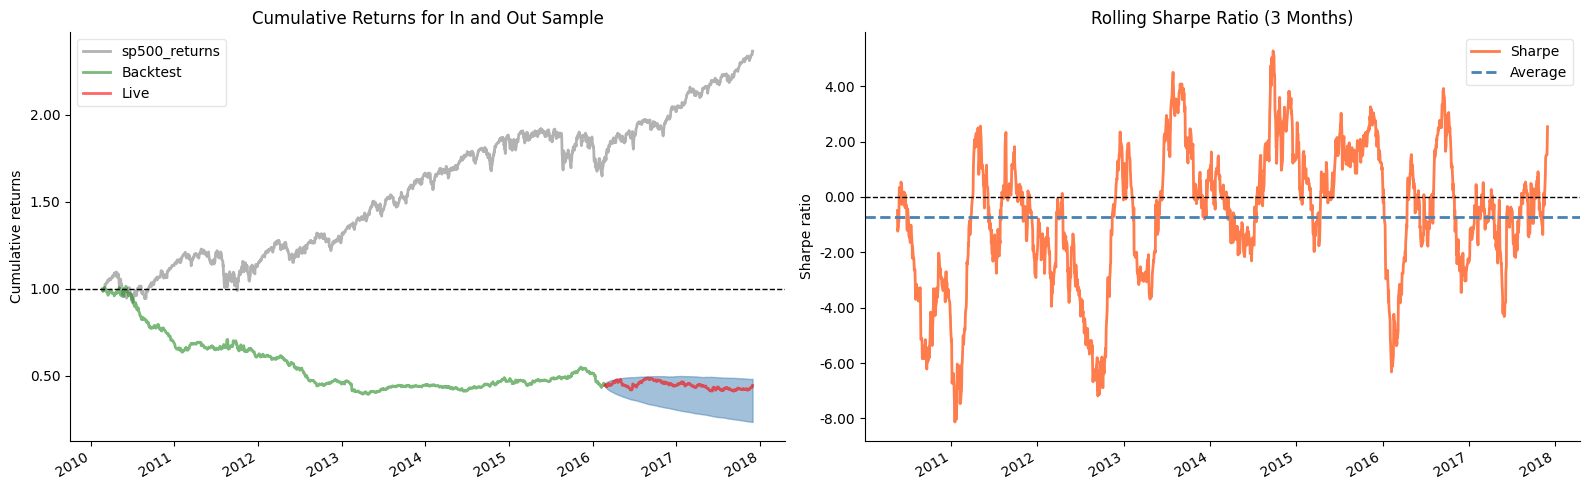

In [16]:
fig,axes=plt.subplots(ncols=2,figsize=(16,5))

plot_rolling_returns(
    returns,
    factor_returns=benchmark_data,
    live_start_date=LIVE_DATE,
    logy=False,
    cone_std=2,
    volatility_match=False,
    legend_loc="best",
    cone_function=forecast_cone_bootstrap,
    ax=axes[0]
)

plot_rolling_sharpe(returns,rolling_window=63,ax=axes[1])

axes[0].set_title("Cumulative Returns for In and Out Sample")
axes[1].set_title("Rolling Sharpe Ratio (3 Months)")

sns.despine()
fig.tight_layout()

#### Full Tear Sheet

Worst drawdown periods,Net drawdown in %,Peak date,Valley date,Recovery date,Duration
0,61.15,2010-06-04,2013-04-29,NaT,NaN
1,5.35,2010-03-04,2010-05-25,2010-06-04,67
2,1.30,2010-02-22,2010-02-26,2010-03-04,9
3,NaN,NaT,NaT,NaT,NaN
4,NaN,NaT,NaT,NaT,NaN


Stress Events,mean,min,max
US downgrade/European Debt Crisis,-0.02%,-3.46%,4.27%
Fukushima,0.06%,-0.77%,0.78%
EZB IR Event,-0.08%,-1.93%,1.43%
Flash Crash,-0.48%,-2.52%,1.21%
Apr14,-0.09%,-2.01%,1.16%
Oct14,-0.01%,-1.27%,2.10%
Fall2015,0.07%,-2.17%,2.26%
Recovery,-0.11%,-3.46%,4.27%
New Normal,0.00%,-8.01%,5.46%


Top 10 long positions of all time,max
sid,
MOS,33.90%
APA,31.16%
DECK,30.72%
HPQ,30.07%
NEM,29.96%
OKE,29.25%
TSN,27.32%
BMY,26.52%
ERIE,26.47%


Top 10 short positions of all time,max
sid,
APA,-36.72%
OKE,-33.84%
WTW,-32.07%
AMD,-31.76%
BMY,-31.60%
ERIE,-31.30%
WEC,-30.86%
CVS,-30.56%
MOS,-29.56%


Top 10 positions of all time,max
sid,
APA,36.72%
MOS,33.90%
OKE,33.84%
WTW,32.07%
AMD,31.76%
BMY,31.60%
ERIE,31.30%
WEC,30.86%
DECK,30.72%


...

PnL stats,All trades,Short trades,Long trades
Total profit,$-574565.66,$-896166.90,$321601.25
Gross profit,$12430135.39,$6043511.08,$6386624.31
Gross loss,$-13004701.04,$-6939677.98,$-6065023.06
Profit factor,$0.96,$0.87,$1.05
Avg. trade net profit,$-7.58,$-24.10,$8.33
Avg. winning trade,$333.48,$342.64,$325.25
Avg. losing trade,$-339.64,$-357.16,$-321.58
Ratio Avg. Win:Avg. Loss,$0.98,$0.96,$1.01
Largest winning trade,$15336.06,$12624.00,$15336.06
Largest losing trade,$-34452.00,$-34452.00,$-20297.75


Duration stats,All trades,Short trades,Long trades
Avg duration,1 days 13:54:27.581099620,1 days 16:59:03.851050098,1 days 10:56:42.573703425
Median duration,1 days 00:00:00,1 days 00:00:00,1 days 00:00:00
Longest duration,193 days 00:00:00,193 days 00:00:00,5 days 03:00:00
Shortest duration,0 days 00:00:00,0 days 00:00:00,0 days 00:00:00


Return stats,All trades,Short trades,Long trades
Avg returns all round_trips,-0.00%,-0.00%,0.00%
Avg returns winning,0.06%,0.06%,0.06%
Avg returns losing,-0.06%,-0.06%,-0.06%
Median returns all round_trips,-0.00%,-0.00%,0.00%
Median returns winning,0.04%,0.04%,0.04%
Median returns losing,-0.04%,-0.04%,-0.03%
Largest winning trade,3.40%,1.97%,3.40%
Largest losing trade,-7.62%,-7.62%,-2.54%


Symbol stats,A,ACGL,ACN,ADI,ADM,ADP,ADSK,AEE,AEP,AES,AFL,AIG,AIZ,AJG,ALB,ALGN,ALL,AMAT,AMD,AME,AMGN,AMP,AMT,AON,AOS,APA,APD,APH,ARE,ATO,AVB,AVGO,AVY,AWK,AXP,AZO,BA,BAC,BAX,BBY,BDX,BEN,BG,BIIB,BK,BLDR,BLK,BMY,BR,BRO,BSX,BXP,C,CAG,CAH,CAT,CB,CCI,CCL,CDNS,CF,CHD,CHRW,CI,CINF,CL,CLX,CME,CMG,CMI,CMS,CNC,CNP,COF,COO,COP,CPB,CPRT,CPT,CRL,CRM,CSCO,CSGP,CSX,CTAS,CTSH,CVS,CVX,D,DAL,DE,DECK,DG,DGX,DHI,DHR,DIS,DLR,DLTR,DOV,DPZ,DRI,DTE,DUK,DVA,DVN,DXCM,EA,EBAY,ECL,ED,EFX,EIX,EL,EMN,EMR,EOG,EQIX,EQR,EQT,ERIE,ES,ESS,ETN,ETR,EW,EXC,EXPD,EXPE,EXR,F,FCX,FDS,FDX,FE,FFIV,FICO,FIS,FITB,FOX,FOXA,FRT,FTNT,GD,GE,GILD,GIS,GLW,GOOGL,GPC,GPN,GRMN,GS,GWW,HAL,HAS,HBAN,HD,HIG,HOLX,HON,HPQ,HRL,HSIC,HST,HSY,HUM,IBM,ICE,IDXX,IEX,IFF,INCY,INTU,IP,IPG,IR,IRM,ISRG,IT,ITW,IVZ,JBHT,JBL,JCI,JKHY,JNJ,JPM,K,KEY,KIM,KLAC,KMB,KMX,KO,KR,L,LDOS,LEN,LH,LII,LKQ,LLY,LMT,LNT,LRCX,LUV,LVS,LYV,MA,MAA,MAR,MAS,MCD,MCHP,MCK,MCO,MDLZ,MDT,MET,MGM,MHK,MKC,MKTX,MLM,MMC,MNST,MO,MOH,MOS,MPWR,MRK,MS,MSCI,MSFT,MSI,MTB,MTD,MU,NDAQ,NDSN,NEE,NEM,NFLX,NI,NKE,NOC,NRG,NSC,NTAP,NTRS,NUE,NVDA,NVR,O,ODFL,OKE,OMC,ORCL,ORLY,OXY,PAYX,PCAR,PCG,PEG,PEP,PFE,PFG,PG,PGR,PH,PHM,PKG,PLD,PM,PNC,PNR,PNW,PODD,POOL,PPG,PPL,PRU,PSA,PWR,RCL,REG,REGN,RF,RJF,RL,RMD,ROK,ROL,ROP,ROST,RSG,SBAC,SBUX,SCHW,SHW,SJM,SLB,SMCI,SNA,SNPS,SO,SPG,SRE,STE,STLD,STT,STX,STZ,SWK,SWKS,SYK,SYY,T,TAP,TDG,TDY,TECH,TEL,TER,TGT,TJX,TMO,TMUS,TRMB,TROW,TSCO,TSN,TTWO,TXN,TXT,TYL,UAL,UDR,UHS,ULTA,UNH,UNP,UPS,URI,USB,V,VLO,VMC,VRSK,VRSN,VRTX,VTR,VZ,WAB,WAT,WBA,WDC,WEC,WFC,WM,WMB,WMT,WRB,WSM,WST,WTW,WY,WYNN,XEL,XOM,YUM,ZBH,ZBRA
Avg returns all round_trips,-0.00%,-0.00%,-0.00%,0.00%,0.00%,0.01%,-0.01%,0.00%,0.00%,-0.00%,-0.01%,-0.01%,-0.00%,0.00%,0.00%,-0.00%,0.01%,-0.00%,-0.02%,-0.00%,-0.00%,0.01%,0.01%,-0.01%,0.00%,-0.00%,0.01%,0.00%,0.01%,-0.01%,-0.01%,0.01%,0.01%,0.00%,-0.00%,-0.01%,0.00%,0.02%,-0.00%,0.01%,0.00%,-0.00%,0.01%,-0.00%,0.00%,0.00%,0.03%,-0.00%,-0.00%,-0.00%,-0.00%,0.00%,0.00%,-0.00%,-0.01%,0.01%,0.00%,-0.00%,-0.00%,-0.01%,0.01%,-0.01%,-0.00%,-0.00%,-0.00%,-0.00%,-0.00%,-0.01%,-0.01%,0.01%,-0.00%,0.01%,-0.00%,0.00%,-0.00%,0.00%,0.00%,-0.00%,0.01%,0.00%,0.01%,-0.00%,-0.01%,-0.00%,0.01%,-0.00%,-0.00%,0.01%,0.01%,-0.01%,0.01%,0.01%,0.00%,0.00%,-0.02%,-0.01%,0.01%,0.00%,0.00%,0.02%,0.00%,0.00%,0.01%,-0.01%,-0.01%,0.02%,0.00%,-0.01%,0.01%,-0.00%,-0.00%,-0.00%,0.00%,-0.00%,-0.00%,0.01%,0.01%,0.01%,-0.02%,0.01%,0.00%,-0.00%,-0.00%,-0.01%,-0.00%,-0.01%,0.01%,-0.00%,0.00%,0.00%,-0.00%,-0.01%,0.01%,-0.00%,0.00%,-0.00%,-0.00%,-0.00%,0.00%,0.01%,0.01%,0.00%,-0.00%,0.01%,-0.00%,0.01%,-0.00%,0.01%,-0.01%,0.00%,0.01%,0.00%,0.02%,-0.00%,0.00%,0.00%,-0.01%,0.00%,0.00%,-0.00%,-0.01%,-0.01%,-0.00%,-0.01%,0.00%,0.01%,0.01%,0.00%,0.00%,-0.02%,-0.01%,-0.00%,-0.01%,-0.00%,-0.01%,-0.03%,-0.01%,0.01%,0.00%,-0.01%,-0.01%,0.02%,0.00%,0.00%,-0.01%,0.00%,0.00%,-0.00%,-0.00%,-0.02%,0.00%,0.00%,-0.00%,-0.01%,-0.01%,-0.00%,-0.01%,-0.00%,0.00%,0.00%,-0.01%,-0.01%,-0.01%,0.00%,0.00%,-0.00%,-0.01%,0.00%,0.02%,0.01%,-0.00%,0.01%,-0.01%,-0.00%,-0.01%,-0.01%,-0.00%,-0.00%,0.00%,-0.01%,0.01%,0.00%,-0.00%,0.01%,-0.00%,-0.00%,0.01%,-0.00%,0.01%,-0.01%,0.00%,0.00%,0.00%,-0.00%,-0.00%,-0.00%,0.01%,0.01%,-0.03%,0.00%,-0.00%,0.00%,-0.00%,0.00%,-0.00%,-0.00%,-0.00%,-0.02%,-0.01%,-0.00%,0.01%,-0.00%,-0.00%,-0.01%,0.01%,-0.01%,0.01%,-0.01%,0.00%,-0.00%,0.00%,-0.01%,0.01%,-0.00%,-0.00%,-0.00%,-0.00%,-0.01%,-0.00%,-0.01%,0.00%,-0.00%,0.01%,-0.00%,0.00%,-0.00%,0.00%,-0.01%,-0.01%,-0.01%,0.00%,-0.00%,-0.01%,0.00%,0.00%,-0.01%,-0.01%,-0.00%,-0.04%,-0.01%,-0.00%,-0.05%,0.01%,-0.00%,0.01%,0.00%,-0.00%,0.00%,0.00%,0.00%,-0.00%,-0.00%,0.01%,-0.02%,0.00%,0.01%,0.00%,-0.00%,-0.01%,0.01%,-0.00%,0.01%,0.00%,-0.05%,-0.00%,0.02%,-0.00%,-0.00%,0.01%,-0.00%,0.00%,0.01%,-0.00%,0.01%,-0.00%,0.01%,0.00%,-0.01%,-0.01%,0.01%,-0.01%,-0.00%,-0.01%,-0.00%,0.00%,0.01%,0.00%,0.01%,-0.01%,-0.00%,-0.01%,-0.00%,0.00%,-0.00%,0.01%,-0.00%,0.00%,-0.01%,-0.01%,0.00%,0.01%,-0.03%,-0.00%,-0.00%,-0.00%,-0.01%,-0.00%,-0.01%,-0.01%,0.01%,-0.01%,-0.03%,-0.01%,0.01%,0.01%,-0.00%,0.01%,0.01%,-0.00%,0.00%,-0.00%,-0.0

Profitability (PnL / PnL total) per name,
symbol,
RMD,9.65%
MU,7.14%
VRTX,6.71%
STZ,6.57%
RF,6.49%
AMD,6.04%
SMCI,5.12%
DAL,4.95%
DHI,4.73%


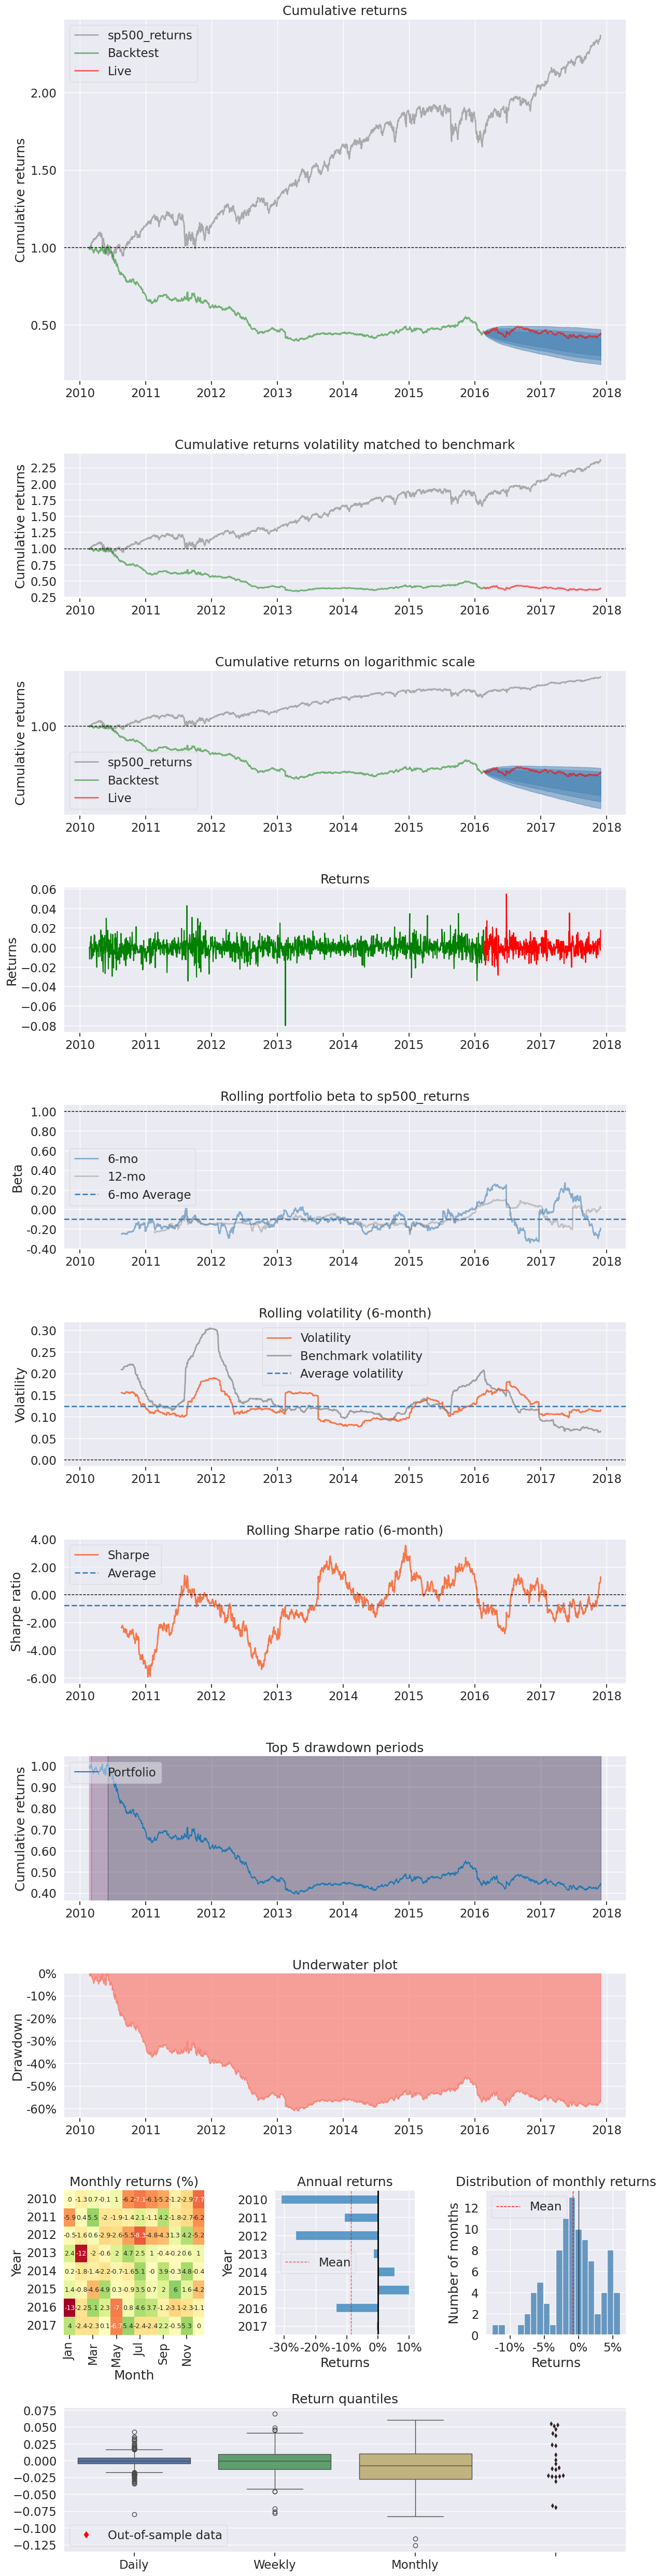

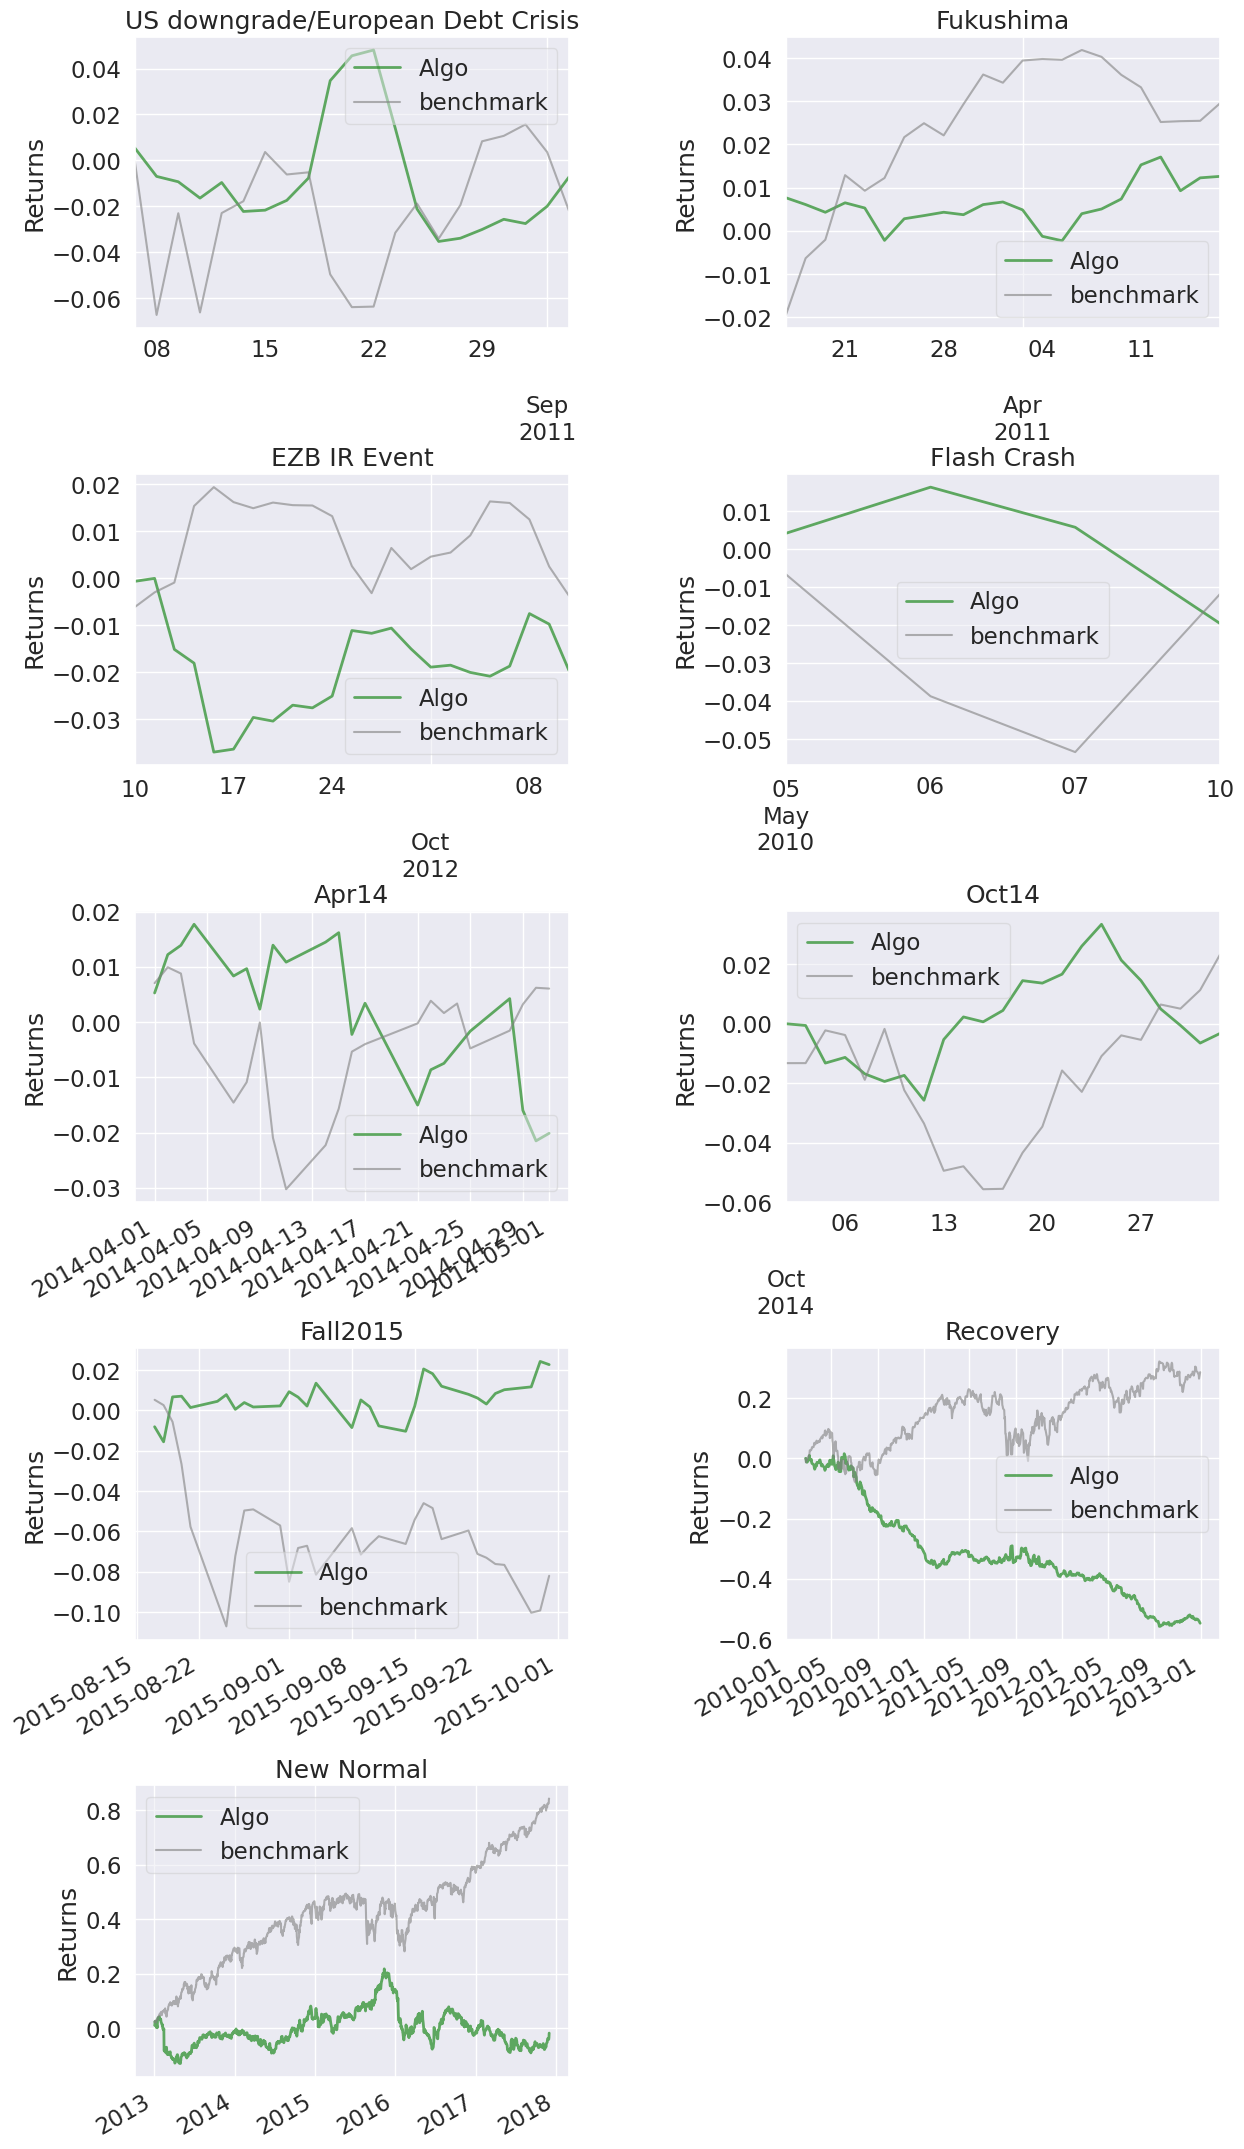

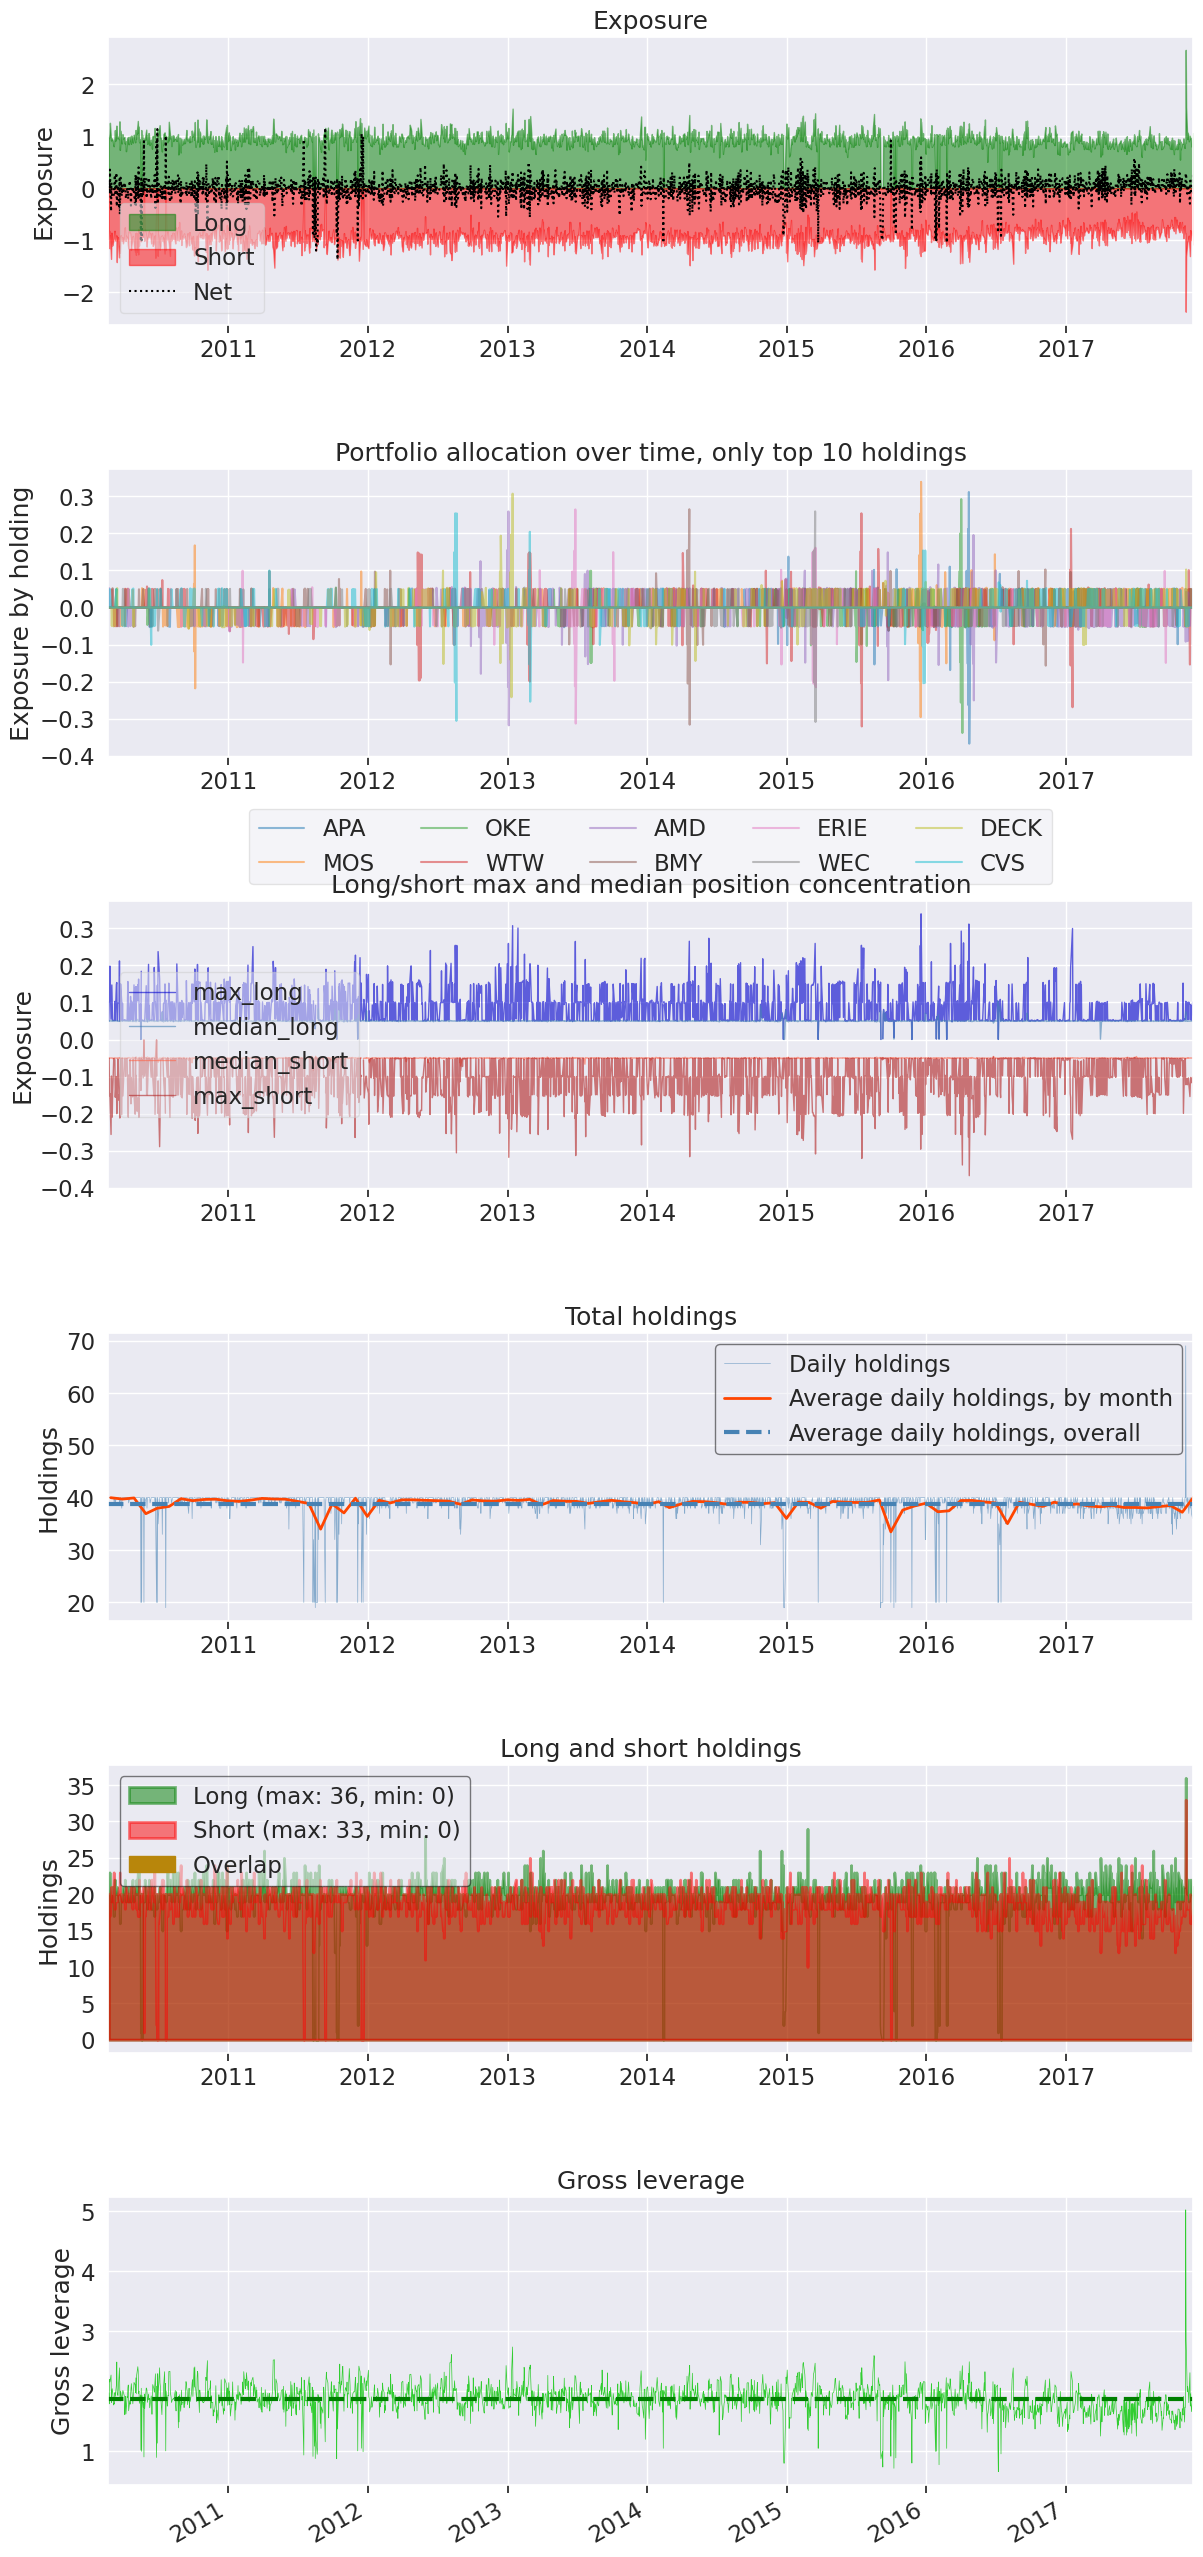

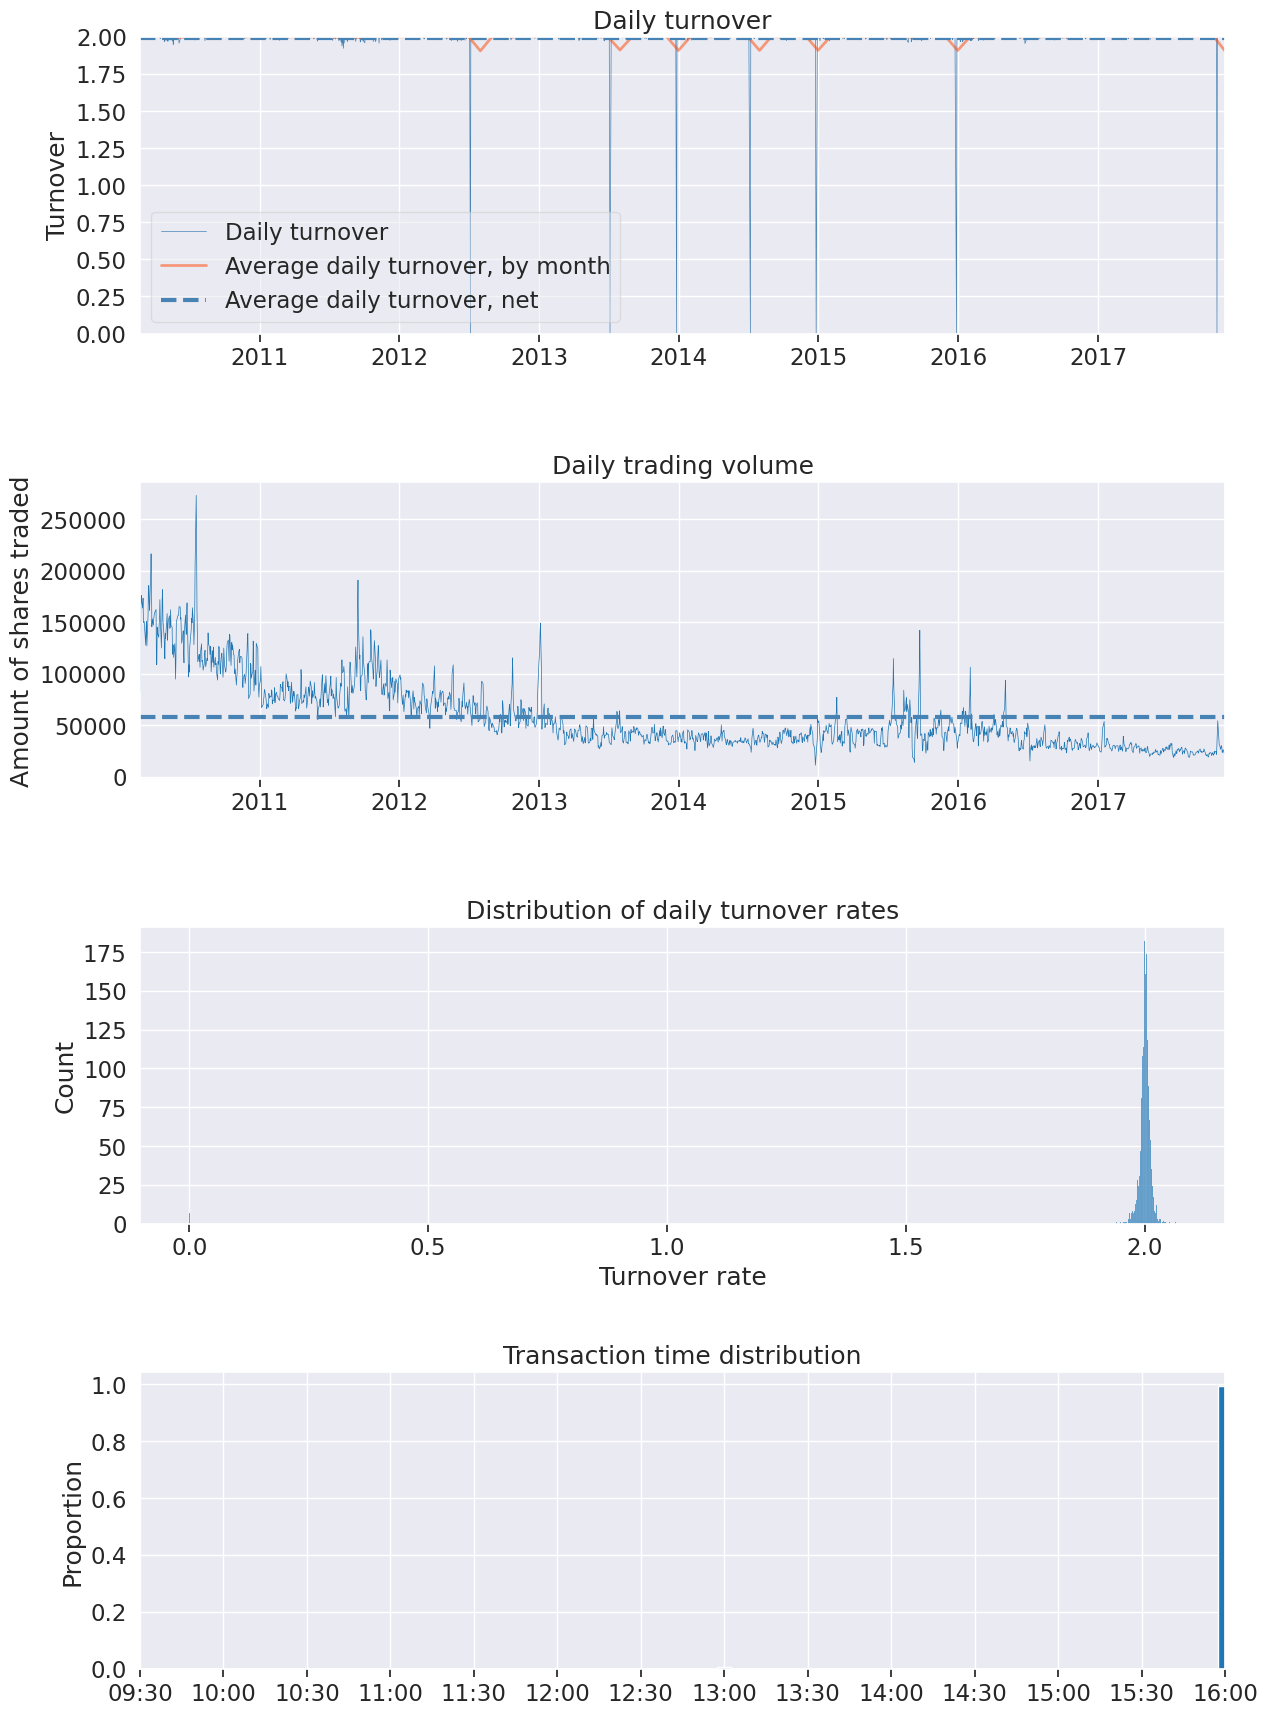

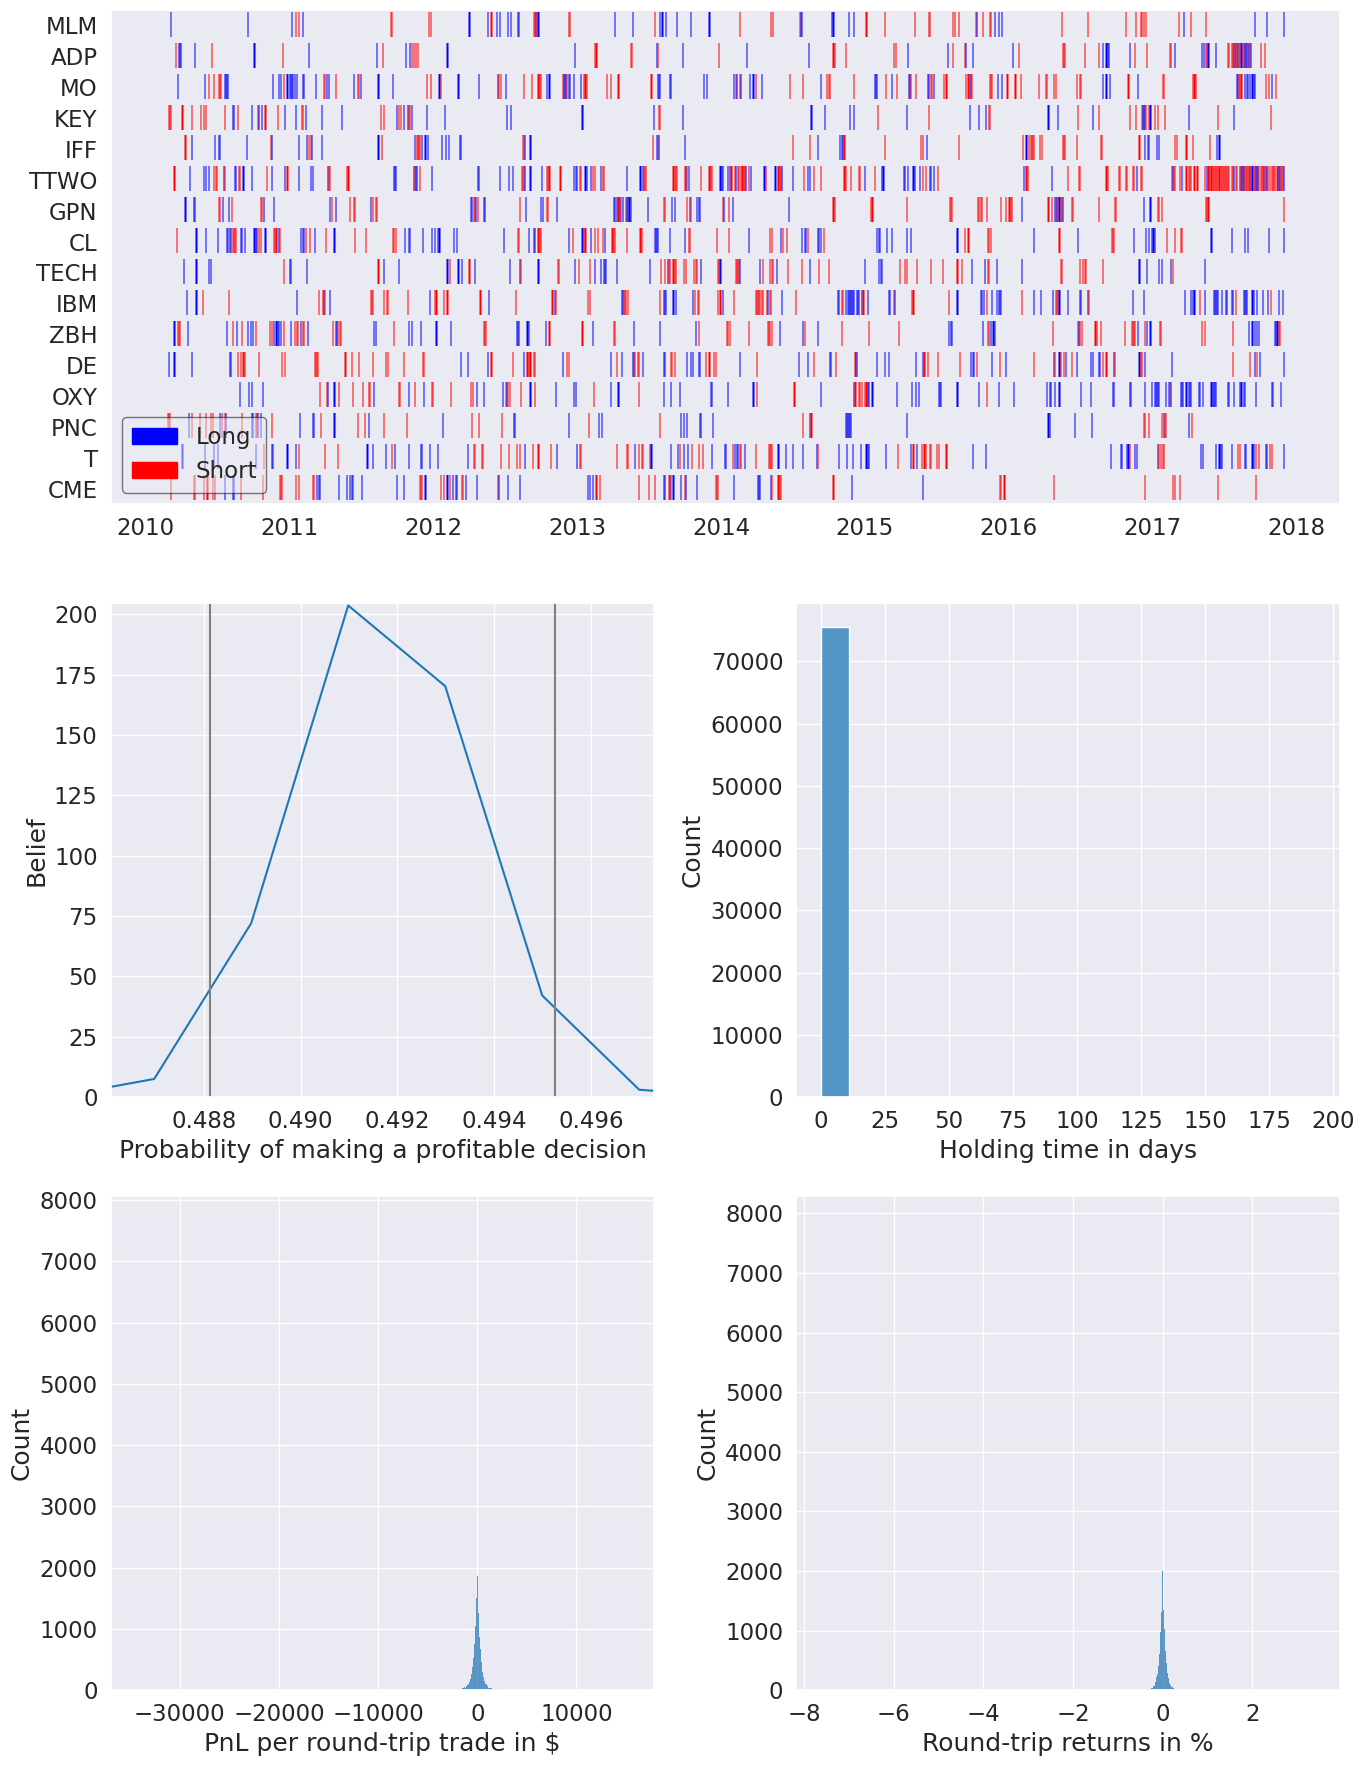

In [17]:
pf.create_full_tear_sheet(
    returns,
    transactions=transactions,
    positions=positions,
    live_start_date=LIVE_DATE,
    benchmark_rets=benchmark_data,
    round_trips=True
)

## Trading Strategy-II

### As seen in signal evaluations of the factors of the Combined Ridge Model, we will long factors in quantile-3 and short factors in quantile-5

In [18]:
trading_strategy={
    "strategy":"quantile_based",
    "values":{
        "quantile_long":3,
        "quantile_short":5
    }
}

In [19]:
backtester=BackTester(
    n_longs=20,
    n_shorts=20,
    min_positions=5,
    capital_base=1e6,
    commission_cost=0.00075,
    commission_min_trade_cost=0.01,
    slippage_spread=0.00,
    predictions_file=os.path.join(data_store,"ridge_factors.csv"),
    predictions_column_name="Combined_factors",
    trading_strategy=trading_strategy
)

In [20]:
results=backtester.run_backtesting()

[INFO]: Model predictions loaded...
[INFO]: Missing Date Values added in Model Predictions...
[INFO]: Model Data Loader created...
[INFO]: Backtesting started for trading strategy-II...
[INFO]: Backtesting completed...


### Performance Analysis using Pyfolio

#### Extracting Information from Zipline Results

In [21]:
returns,positions,transactions=pf.utils.extract_rets_pos_txn_from_zipline(results)

#### Plotting Rolling Returns and Sharpe

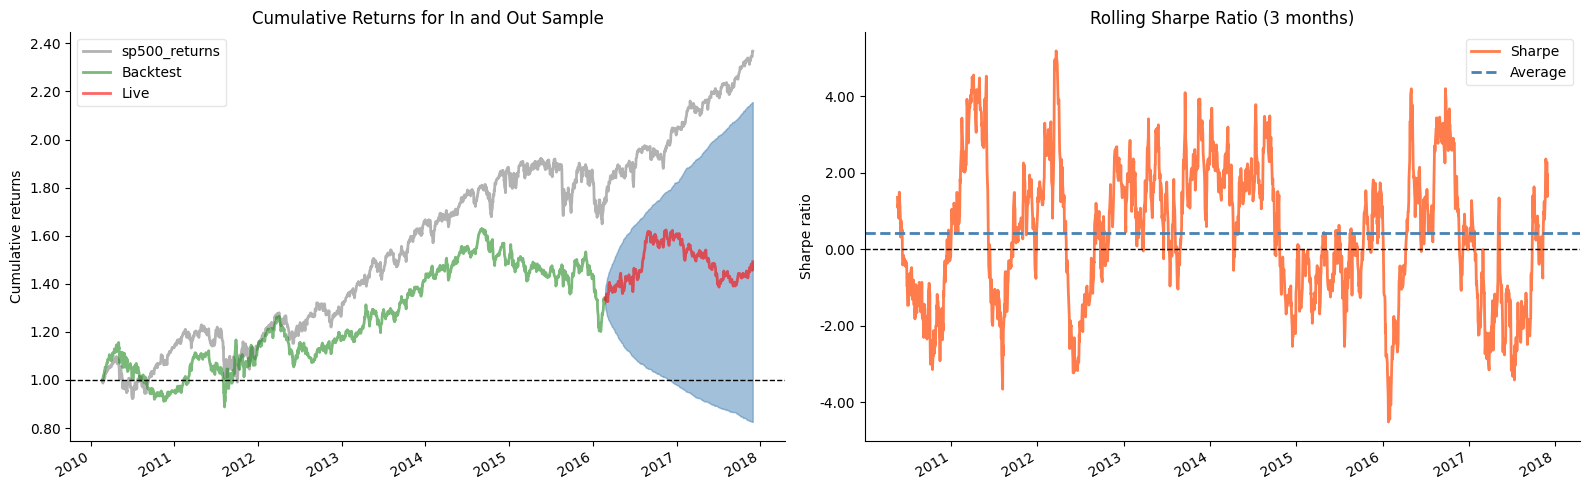

In [22]:
fig,axes=plt.subplots(ncols=2,figsize=(16,5))

plot_rolling_returns(
    returns,
    factor_returns=benchmark_data,
    live_start_date=LIVE_DATE,
    logy=False,
    cone_std=2,
    legend_loc="best",
    volatility_match=False,
    cone_function=forecast_cone_bootstrap,
    ax=axes[0]
)

plot_rolling_sharpe(returns,rolling_window=63,ax=axes[1])

axes[0].set_title("Cumulative Returns for In and Out Sample")
axes[1].set_title("Rolling Sharpe Ratio (3 months)")

sns.despine()
fig.tight_layout()

#### Full Tear Sheet

Worst drawdown periods,Net drawdown in %,Peak date,Valley date,Recovery date,Duration
0,26.25,2014-09-05,2016-02-05,NaT,NaN
1,23.19,2010-05-03,2011-08-08,2011-09-27,367
2,16.65,2012-04-02,2012-06-05,2013-04-15,271
3,13.19,2011-09-27,2011-11-01,2012-01-20,84
4,8.83,2013-04-16,2013-06-19,2013-09-10,106


Stress Events,mean,min,max
US downgrade/European Debt Crisis,0.42%,-6.46%,6.20%
Fukushima,0.18%,-1.30%,1.81%
EZB IR Event,0.11%,-1.10%,1.26%
Flash Crash,-0.37%,-3.62%,3.89%
Apr14,0.04%,-2.16%,1.44%
Oct14,-0.24%,-1.97%,1.76%
Fall2015,-0.14%,-4.39%,2.53%
Recovery,0.03%,-6.46%,6.20%
New Normal,0.02%,-4.39%,3.94%


Top 10 long positions of all time,max
sid,
AFL,24.47%
LEN,23.90%
AOS,20.97%
ACGL,20.59%
NEM,20.50%
MGM,19.97%
HPQ,19.77%
DECK,19.60%
TAP,19.54%


Top 10 short positions of all time,max
sid,
ACGL,-25.65%
TMO,-24.51%
RL,-21.05%
DVN,-20.54%
UHS,-20.26%
DLTR,-20.25%
HSIC,-20.17%
IT,-20.16%
LLY,-20.04%


Top 10 positions of all time,max
sid,
ACGL,25.65%
TMO,24.51%
AFL,24.47%
LEN,23.90%
RL,21.05%
AOS,20.97%
DVN,20.54%
NEM,20.50%
UHS,20.26%


...

PnL stats,All trades,Short trades,Long trades
Total profit,$410919.16,$-299874.58,$710793.73
Gross profit,$18132742.93,$5784217.69,$12348525.24
Gross loss,$-17721823.77,$-6084092.27,$-11637731.50
Profit factor,$1.02,$0.95,$1.06
Avg. trade net profit,$8.68,$-20.71,$21.64
Avg. winning trade,$760.95,$834.54,$730.77
Avg. losing trade,$-768.24,$-819.19,$-744.05
Ratio Avg. Win:Avg. Loss,$0.99,$1.02,$0.98
Largest winning trade,$33393.86,$33393.86,$16353.86
Largest losing trade,$-36500.77,$-22553.00,$-36500.77


Duration stats,All trades,Short trades,Long trades
Avg duration,1 days 14:14:44.064589055,1 days 22:11:26.577813082,1 days 10:44:40.083706206
Median duration,1 days 00:00:00,1 days 00:00:00,1 days 00:00:00
Longest duration,140 days 23:00:00,140 days 23:00:00,5 days 03:00:00
Shortest duration,0 days 00:00:00,0 days 00:00:00,0 days 20:59:59


Return stats,All trades,Short trades,Long trades
Avg returns all round_trips,0.00%,-0.00%,0.00%
Avg returns winning,0.06%,0.06%,0.06%
Avg returns losing,-0.06%,-0.06%,-0.06%
Median returns all round_trips,0.00%,-0.00%,0.00%
Median returns winning,0.04%,0.04%,0.04%
Median returns losing,-0.04%,-0.04%,-0.04%
Largest winning trade,2.45%,2.45%,1.07%
Largest losing trade,-2.55%,-1.88%,-2.55%


Symbol stats,A,ACGL,ACN,ADI,ADM,ADP,ADSK,AEE,AEP,AES,AFL,AIG,AIZ,AJG,ALB,ALGN,ALL,AMAT,AMD,AME,AMGN,AMP,AMT,AON,AOS,APA,APD,APH,ARE,ATO,AVB,AVGO,AVY,AWK,AXP,AZO,BA,BAC,BAX,BBY,BDX,BEN,BG,BIIB,BK,BLDR,BLK,BMY,BR,BRO,BSX,BXP,C,CAG,CAH,CAT,CB,CCI,CCL,CDNS,CF,CHD,CHRW,CI,CINF,CL,CLX,CME,CMG,CMI,CMS,CNC,CNP,COF,COO,COP,CPB,CPRT,CPT,CRL,CRM,CSCO,CSGP,CSX,CTAS,CTSH,CVS,CVX,D,DAL,DE,DECK,DG,DGX,DHI,DHR,DIS,DLR,DLTR,DOV,DPZ,DRI,DTE,DUK,DVA,DVN,DXCM,EA,EBAY,ECL,ED,EFX,EIX,EL,EMN,EMR,EOG,EQIX,EQR,EQT,ERIE,ES,ESS,ETN,ETR,EW,EXC,EXPD,EXPE,EXR,F,FCX,FDS,FDX,FE,FFIV,FICO,FIS,FITB,FOX,FOXA,FRT,FTNT,GD,GE,GILD,GIS,GLW,GOOGL,GPC,GPN,GRMN,GS,GWW,HAL,HAS,HBAN,HD,HIG,HOLX,HON,HPQ,HRL,HSIC,HST,HSY,HUM,IBM,ICE,IDXX,IEX,IFF,INCY,INTU,IP,IPG,IR,IRM,ISRG,IT,ITW,IVZ,JBHT,JBL,JCI,JKHY,JNJ,JPM,K,KEY,KIM,KLAC,KMB,KMX,KO,KR,L,LDOS,LEN,LH,LII,LKQ,LLY,LMT,LNT,LRCX,LUV,LVS,LYV,MA,MAA,MAR,MAS,MCD,MCHP,MCK,MCO,MDLZ,MDT,MET,MGM,MHK,MKC,MKTX,MLM,MMC,MNST,MO,MOH,MOS,MPWR,MRK,MS,MSCI,MSFT,MSI,MTB,MTD,MU,NDAQ,NDSN,NEE,NEM,NFLX,NI,NKE,NOC,NRG,NSC,NTAP,NTRS,NUE,NVDA,NVR,O,ODFL,OKE,OMC,ORCL,ORLY,OXY,PAYX,PCAR,PCG,PEG,PEP,PFE,PFG,PG,PGR,PH,PHM,PKG,PLD,PM,PNC,PNR,PNW,PODD,POOL,PPG,PPL,PRU,PSA,PWR,RCL,REG,REGN,RF,RJF,RL,RMD,ROK,ROL,ROP,ROST,RSG,SBAC,SBUX,SCHW,SHW,SJM,SLB,SMCI,SNA,SNPS,SO,SPG,SRE,STE,STLD,STT,STX,STZ,SWK,SWKS,SYK,SYY,T,TAP,TDG,TDY,TECH,TEL,TER,TGT,TJX,TMO,TMUS,TRMB,TROW,TSCO,TSN,TTWO,TXN,TXT,TYL,UAL,UDR,UHS,ULTA,UNH,UNP,UPS,URI,USB,V,VLO,VMC,VRSK,VRSN,VRTX,VTR,VZ,WAB,WAT,WBA,WDC,WEC,WFC,WM,WMB,WMT,WRB,WSM,WST,WTW,WY,WYNN,XEL,XOM,YUM,ZBH,ZBRA
Avg returns all round_trips,-0.00%,0.00%,0.01%,0.01%,-0.02%,0.01%,-0.01%,0.00%,0.01%,0.00%,-0.01%,0.00%,0.00%,-0.00%,0.01%,-0.01%,0.00%,0.00%,-0.01%,0.02%,-0.01%,-0.00%,0.00%,-0.00%,0.01%,-0.01%,0.01%,-0.00%,-0.01%,-0.00%,-0.00%,-0.01%,0.00%,-0.01%,0.01%,-0.01%,0.01%,0.01%,-0.00%,0.02%,-0.00%,0.01%,0.01%,-0.01%,0.01%,-0.03%,0.01%,0.00%,0.00%,-0.01%,0.01%,-0.00%,-0.01%,0.00%,0.01%,0.01%,-0.00%,-0.00%,0.01%,-0.01%,0.03%,-0.00%,-0.00%,0.00%,0.01%,-0.01%,-0.00%,0.01%,-0.02%,0.02%,0.00%,-0.01%,0.01%,0.02%,0.00%,-0.00%,0.00%,0.00%,-0.01%,0.00%,-0.01%,0.00%,0.01%,0.01%,0.01%,-0.01%,-0.00%,0.01%,0.01%,-0.02%,-0.01%,-0.00%,0.00%,0.00%,-0.01%,-0.00%,-0.00%,0.01%,-0.01%,0.00%,0.01%,-0.01%,0.00%,-0.01%,-0.00%,0.00%,0.01%,0.01%,0.01%,-0.00%,-0.00%,0.00%,0.01%,-0.01%,0.01%,-0.01%,-0.01%,0.00%,-0.00%,0.01%,0.00%,0.00%,-0.00%,-0.00%,0.00%,-0.01%,-0.00%,-0.00%,-0.00%,-0.02%,-0.01%,-0.01%,0.00%,0.02%,0.00%,0.01%,0.02%,-0.00%,0.01%,0.01%,0.01%,0.01%,0.02%,-0.00%,0.00%,-0.00%,0.00%,0.00%,-0.01%,-0.00%,-0.00%,0.00%,-0.00%,0.00%,-0.00%,-0.00%,0.01%,-0.00%,-0.01%,-0.00%,0.01%,-0.00%,-0.00%,-0.02%,0.03%,0.00%,0.01%,-0.00%,0.01%,-0.04%,0.01%,0.00%,-0.01%,-0.00%,0.00%,-0.00%,-0.00%,0.01%,0.00%,-0.01%,0.00%,0.01%,0.01%,-0.01%,-0.01%,-0.00%,-0.00%,0.00%,-0.00%,0.00%,0.00%,0.00%,0.00%,-0.00%,-0.00%,0.00%,0.01%,0.01%,-0.01%,-0.01%,0.02%,-0.00%,-0.01%,0.01%,-0.00%,-0.00%,-0.00%,0.01%,-0.00%,0.01%,-0.00%,0.01%,0.01%,-0.00%,-0.00%,-0.00%,-0.00%,0.00%,0.01%,-0.00%,0.02%,-0.00%,-0.01%,0.01%,0.00%,-0.00%,0.01%,0.01%,-0.01%,-0.01%,-0.01%,0.00%,0.02%,-0.00%,-0.00%,0.01%,0.01%,-0.01%,-0.01%,-0.02%,0.01%,-0.00%,0.01%,-0.00%,-0.00%,0.01%,0.01%,0.00%,0.00%,-0.00%,-0.00%,-0.01%,-0.01%,-0.02%,0.01%,0.00%,0.00%,-0.00%,0.00%,0.00%,-0.01%,0.00%,-0.01%,-0.00%,-0.00%,0.00%,0.00%,0.01%,0.00%,-0.00%,0.01%,0.01%,-0.00%,0.00%,-0.00%,-0.00%,-0.02%,-0.00%,-0.01%,0.00%,0.02%,0.00%,-0.00%,-0.00%,0.01%,0.00%,-0.00%,-0.02%,-0.01%,-0.00%,-0.01%,-0.00%,-0.01%,0.00%,0.01%,0.00%,0.01%,0.00%,0.01%,0.01%,0.01%,-0.00%,0.00%,-0.00%,0.00%,0.01%,0.01%,-0.00%,0.00%,0.01%,0.00%,0.01%,-0.00%,-0.01%,0.00%,0.02%,0.00%,-0.00%,0.00%,0.01%,0.00%,0.00%,-0.00%,-0.01%,0.00%,0.00%,0.01%,-0.02%,0.00%,-0.01%,-0.00%,0.01%,0.00%,0.01%,0.01%,0.01%,0.02%,0.01%,-0.00%,0.01%,0.02%,-0.01%,0.01%,-0.01%,0.02%,0.01%,-0.00%,0.01%,-0.01%,-0.00%,-0.00%,0.01%,0.01%,-0.01%,-0.01%,-0.00%,-0.02%,0.02%,0.01%,0.01%,0.00%,-0.00%,0.00%,0.01%,-0.01%,0.00%,0.02%,0.01%,0.01%,0.00%,-0.00%,0.01%,0.01%,0.00%
Avg returns winning

Profitability (PnL / PnL total) per name,
symbol,
CF,15.09%
WTW,13.23%
BBY,10.09%
SWKS,9.63%
ULTA,9.07%
COF,8.24%
HST,8.11%
WDC,7.93%
PPG,7.69%


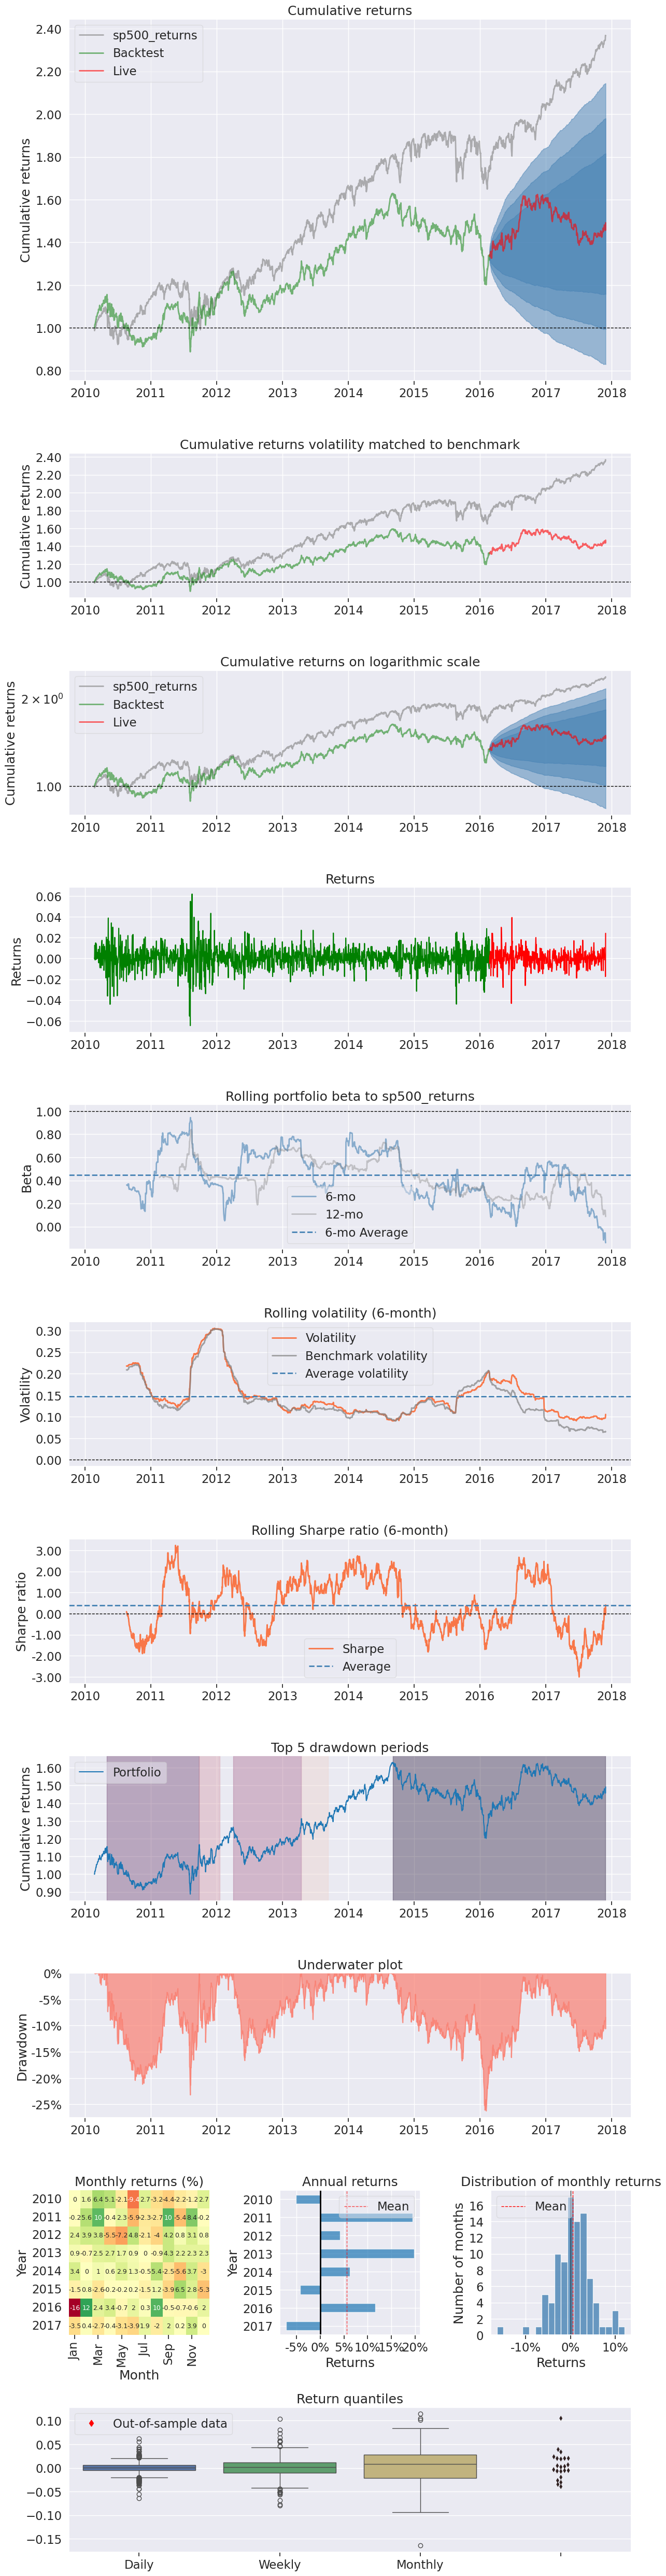

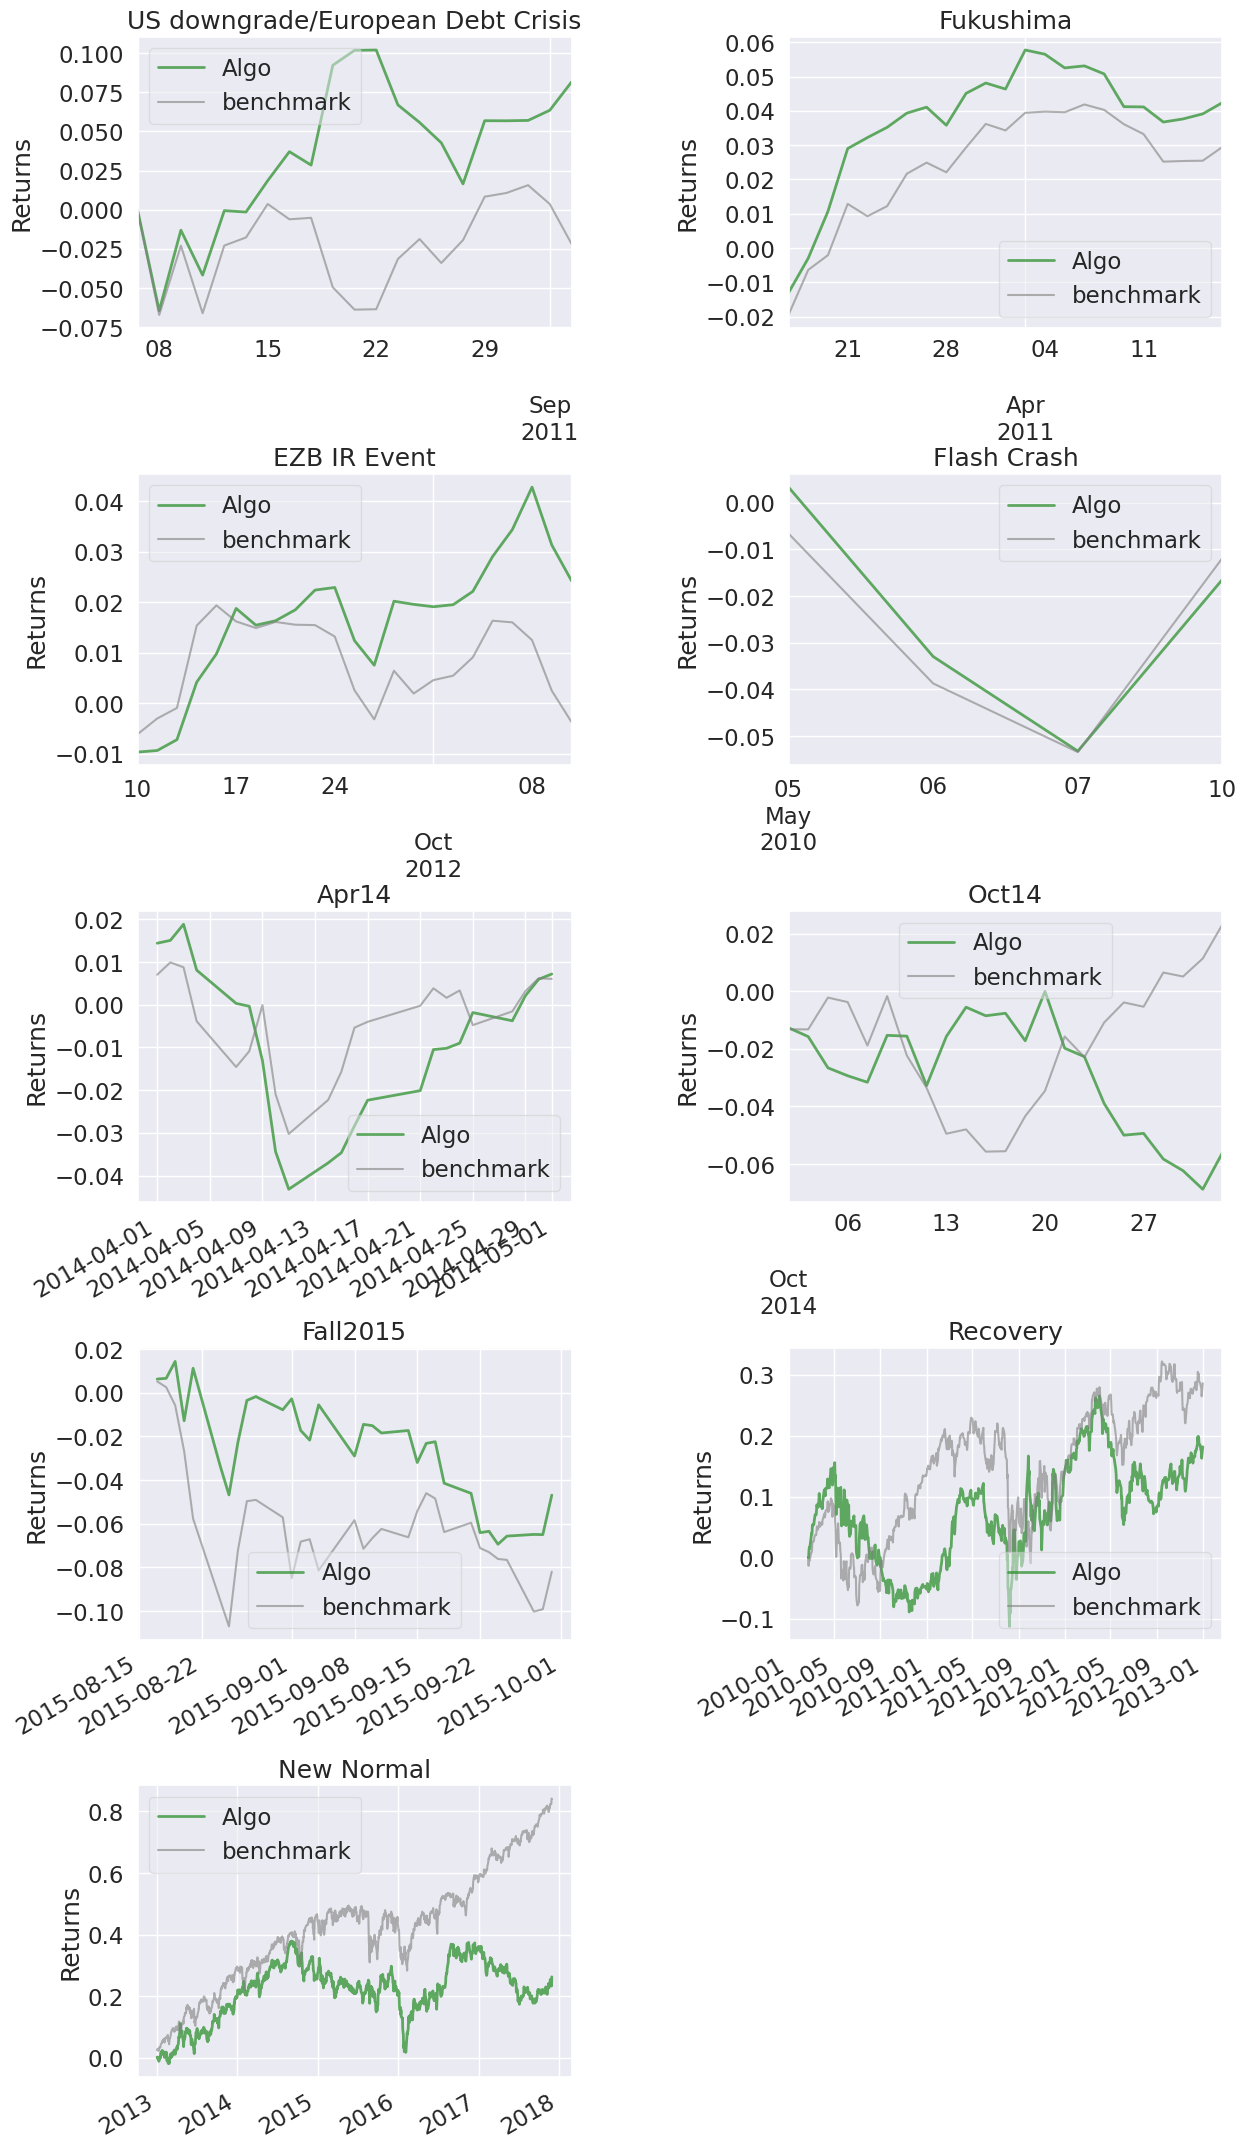

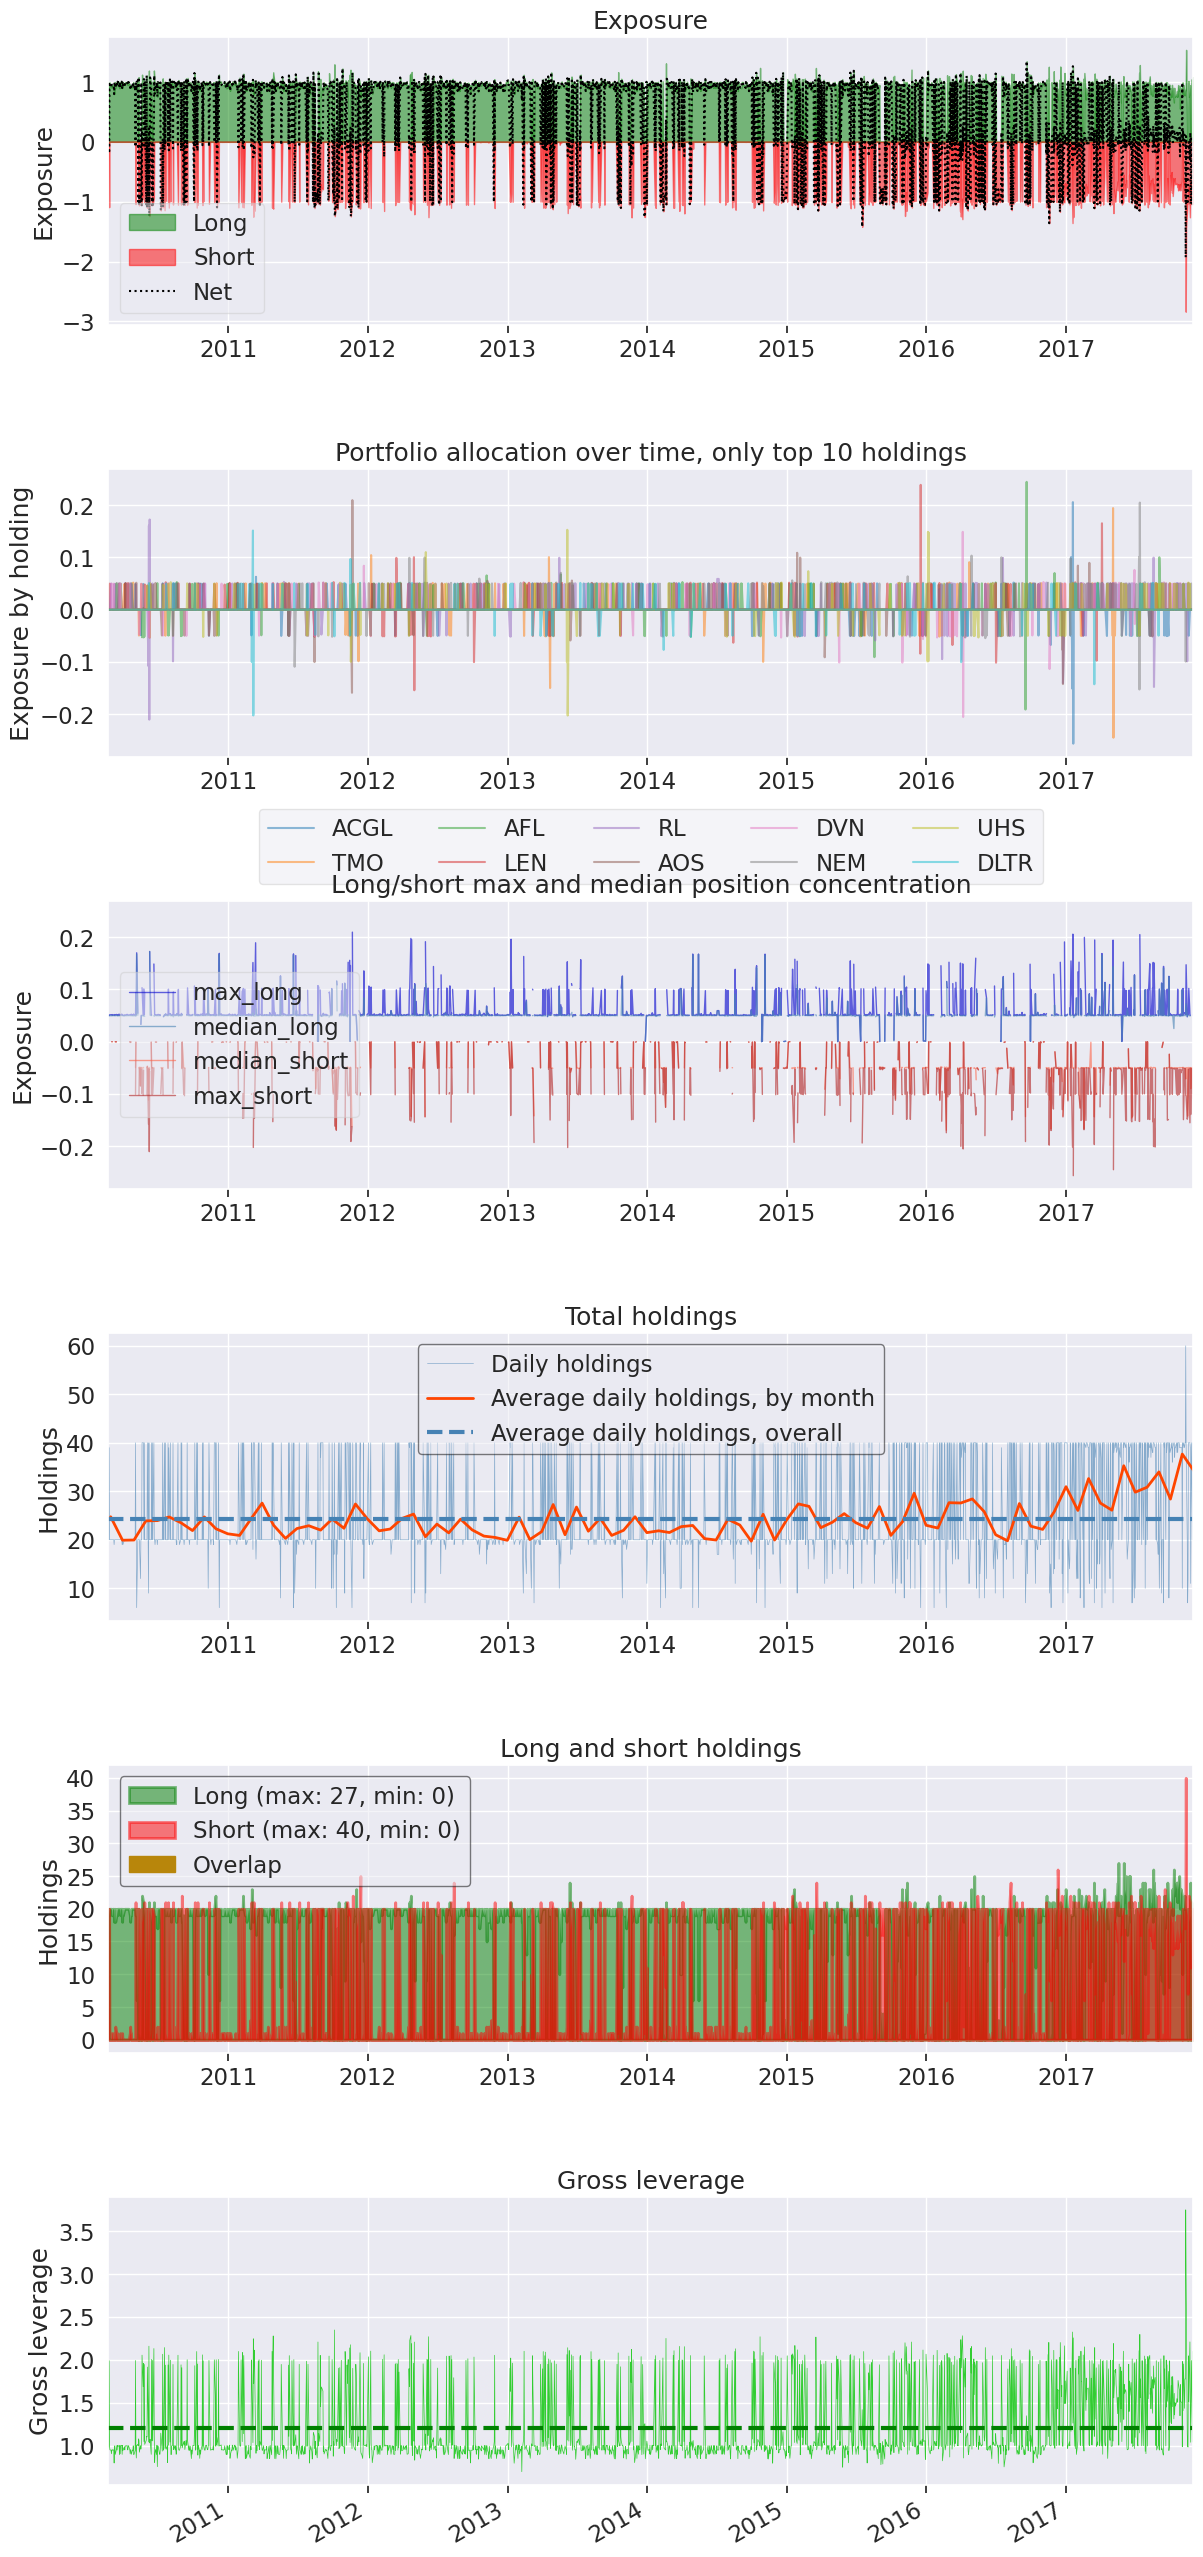

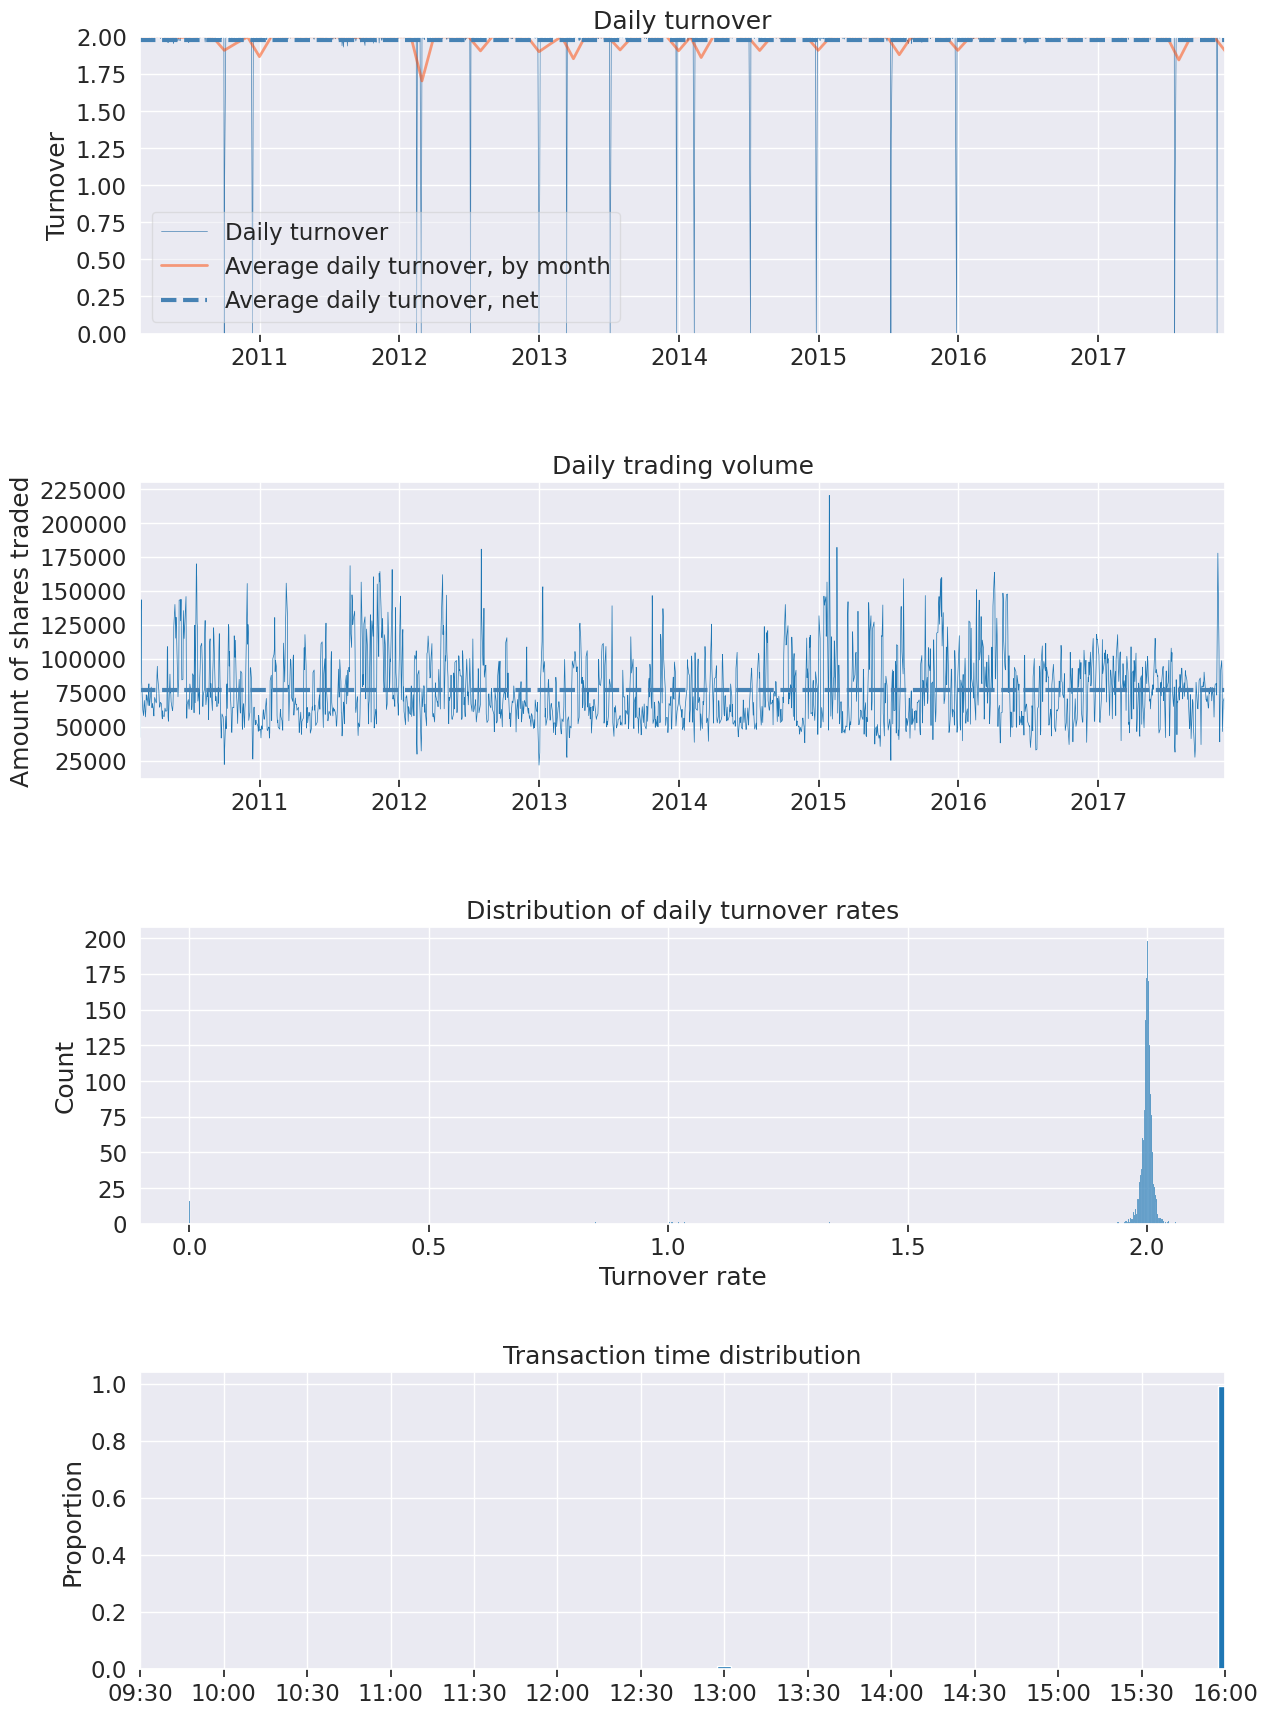

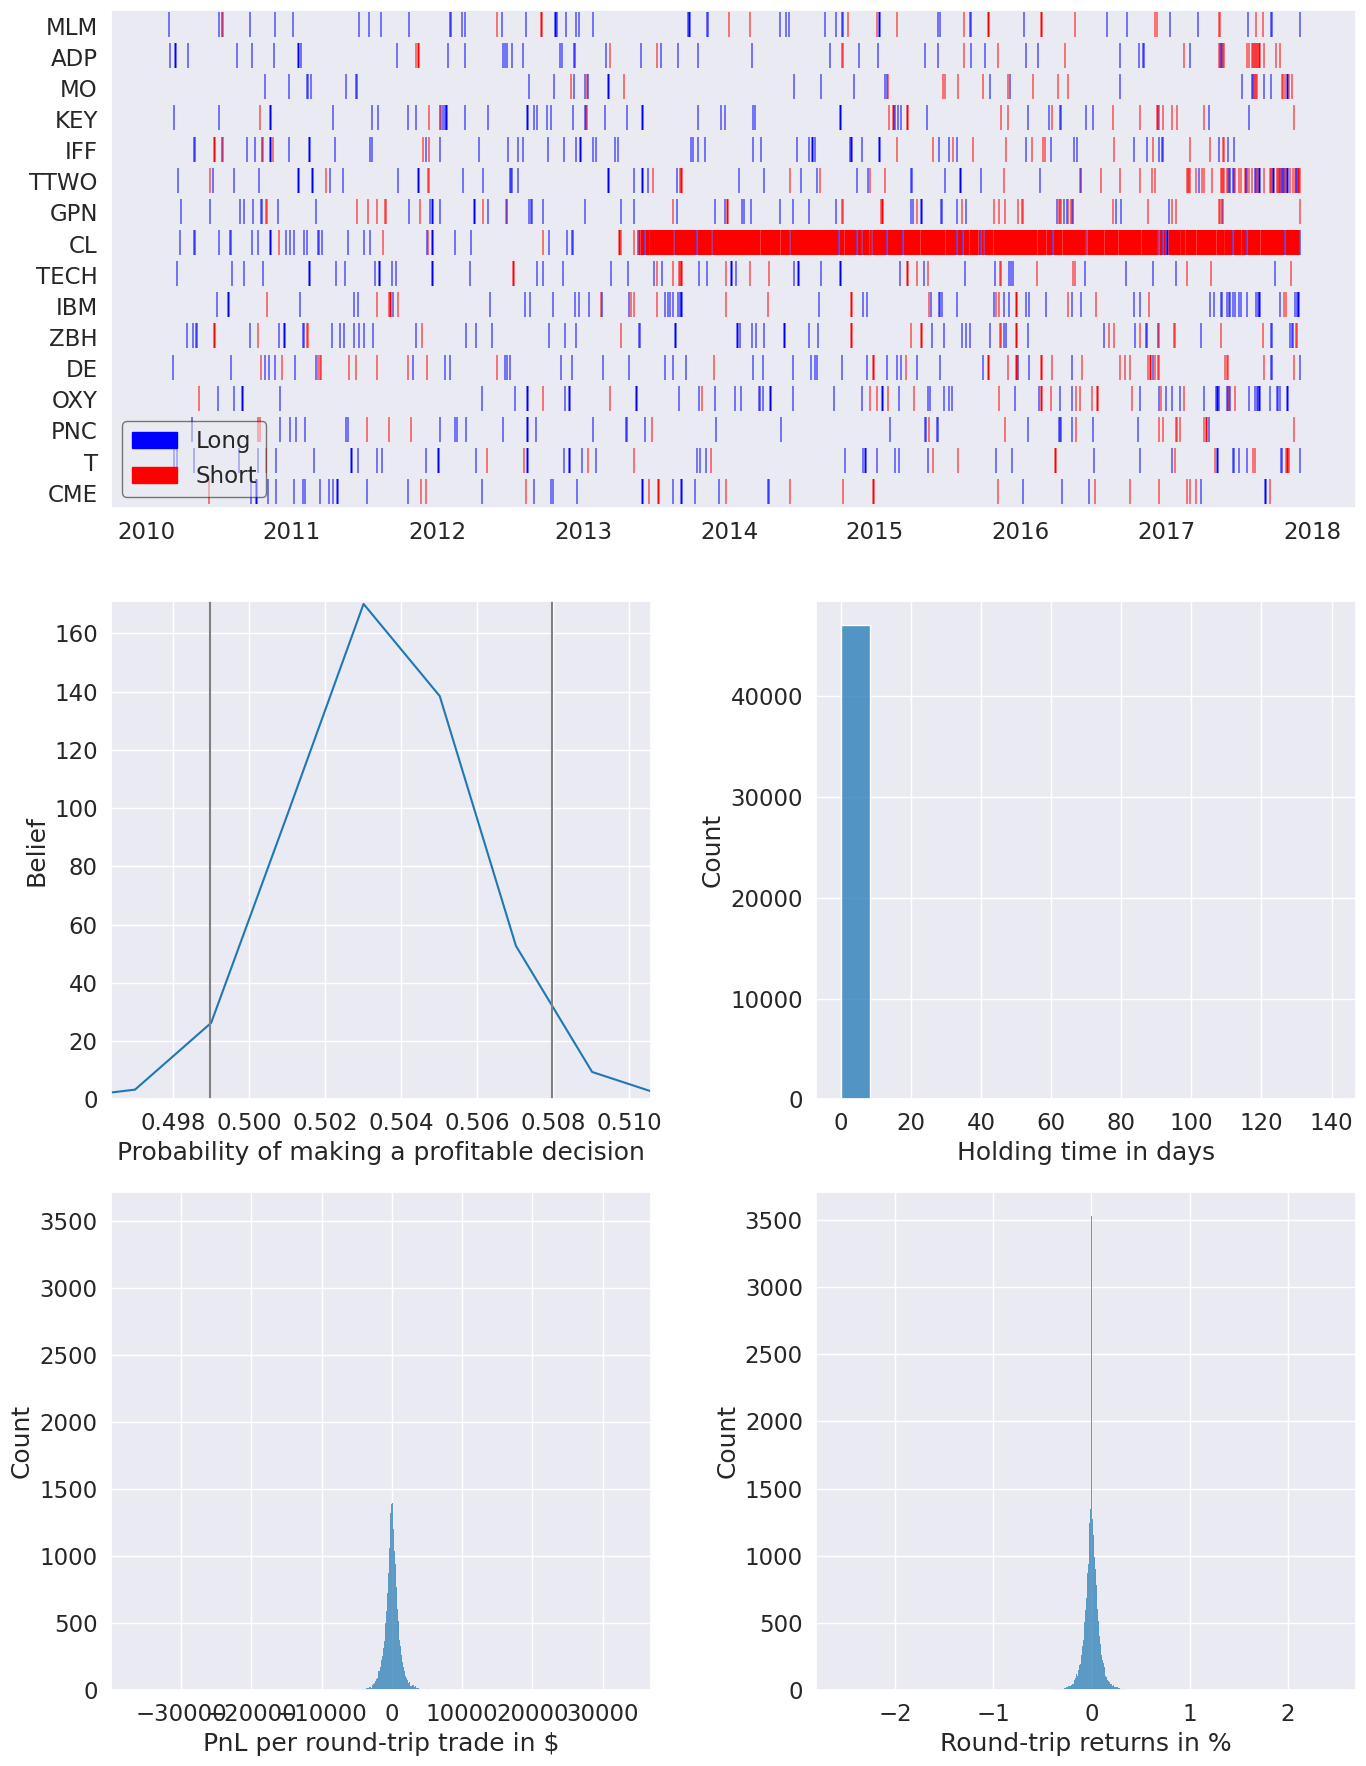

In [23]:
pf.create_full_tear_sheet(
    returns,
    positions=positions,
    transactions=transactions,
    benchmark_rets=benchmark_data,
    live_start_date=LIVE_DATE,
    round_trips=True
)